# EDA (Exploratory Data Analisis) — Estrategia E1 Conservative (GRU, 90 días)

Análisis exploratorio de datos para la estrategia conservadora de largo plazo.

**Tickers**: 5 argentinos (.BA) + 5 estadounidenses  
**Horizonte**: 90 días  
**Modelo**: GRU  
**Features**: 13 indicadores técnicos  
**Datos**: OHLCV diario (~10 años)

## 0. Setup

In [19]:
import sys
from pathlib import Path

# Agregar raíz del proyecto al path para poder importar módulos de src/
# Como este notebook vive en notebooks/eda/, subimos 2 niveles (../../)
ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Librerías de datos y visualización ---
import numpy as np       # Operaciones numéricas (log, arrays, etc.)
import pandas as pd      # DataFrames para datos tabulares
import matplotlib.pyplot as plt  # Gráficos base
import seaborn as sns    # Gráficos estadísticos (heatmaps, boxplots, etc.)
from scipy import stats  # Tests estadísticos (Jarque-Bera, Q-Q, Pearson, etc.)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Autocorrelación

# --- Módulos del proyecto ---
from src.utils import project_root, load_yaml              # Utilidades: ruta raíz, cargar YAML
from src.e1.build_features import compute_e1_features, make_target_e1  # Features técnicos y target
from src.e1.train_pipeline import load_ohlcv_csv           # Carga de CSV con parsing de timestamps
from src.data.clean_daily import diagnose_data_quality      # Diagnóstico de calidad de datos

# --- Estilo global de gráficos ---
sns.set_theme(style="whitegrid", palette="muted")  # Fondo con grilla suave, colores apagados
plt.rcParams["figure.figsize"] = (14, 6)           # Tamaño por defecto de figuras
plt.rcParams["figure.dpi"] = 100                   # Resolución de pantalla

print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict


In [20]:
# --- Cargar configuración central del proyecto ---
# base.yaml contiene todos los parámetros: tickers, horizonte, lookback, modelo, etc.
cfg = load_yaml(project_root() / "src" / "config" / "base.yaml")

# Extraer la lista de 10 tickers asignados a la estrategia E1
E1_TICKERS = cfg["universe"]["tickers_by_strategy"]["e1_conservative"]

# Extraer parámetros de la estrategia E1
E1_CFG = cfg["strategies"]["e1_conservative"]
HORIZON = E1_CFG["horizon_days"]   # 90 días: cuánto hacia el futuro predecimos
LOOKBACK = E1_CFG["lookback_days"] # 360 días: cuántos días de historia ve el modelo como input

# --- Clasificar tickers por mercado ---
# Los tickers argentinos terminan en ".BA" (Buenos Aires)
AR_TICKERS = [t for t in E1_TICKERS if t.endswith(".BA")]
US_TICKERS = [t for t in E1_TICKERS if not t.endswith(".BA")]

print(f"Tickers E1: {E1_TICKERS}")
print(f"  AR ({len(AR_TICKERS)}): {AR_TICKERS}")
print(f"  US ({len(US_TICKERS)}): {US_TICKERS}")
print(f"Horizonte: {HORIZON} días | Lookback: {LOOKBACK} días")

Tickers E1: ['YPFD.BA', 'GGAL.BA', 'PAMP.BA', 'BYMA.BA', 'CEPU.BA', 'AAPL', 'MSFT', 'JNJ', 'PG', 'V']
  AR (5): ['YPFD.BA', 'GGAL.BA', 'PAMP.BA', 'BYMA.BA', 'CEPU.BA']
  US (5): ['AAPL', 'MSFT', 'JNJ', 'PG', 'V']
Horizonte: 90 días | Lookback: 360 días


In [21]:
# --- Cargar datos OHLCV limpios (post-cleaning) para cada ticker ---
# Los CSV limpios están en data/clean/ con formato: timestamp, open, high, low, close, volume
# load_ohlcv_csv() parsea timestamps a datetime UTC y valida que existan las columnas requeridas.
# El resultado es un DataFrame indexado por timestamp (DatetimeIndex).
clean_dir = project_root() / "data" / "clean"
data = {}  # Diccionario {ticker: DataFrame_OHLCV}

for ticker in E1_TICKERS:
    path = clean_dir / f"{ticker}_daily.csv"
    if path.exists():
        data[ticker] = load_ohlcv_csv(path)
        print(f"  {ticker}: {len(data[ticker]):,} días "
              f"| {data[ticker].index.min().date()} → {data[ticker].index.max().date()}")
    else:
        print(f"  ⚠️ {ticker}: archivo no encontrado en {path}")

print(f"\nTickers cargados: {len(data)}/{len(E1_TICKERS)}")

  YPFD.BA: 2,432 días | 2016-02-29 → 2026-02-24
  GGAL.BA: 2,433 días | 2016-02-29 → 2026-02-24
  PAMP.BA: 2,432 días | 2016-02-25 → 2026-02-25
  BYMA.BA: 2,109 días | 2017-06-26 → 2026-02-25
  CEPU.BA: 2,398 días | 2016-02-25 → 2026-02-25
  AAPL: 2,515 días | 2016-02-25 → 2026-02-25
  MSFT: 2,515 días | 2016-02-25 → 2026-02-25
  JNJ: 2,515 días | 2016-02-25 → 2026-02-25
  PG: 2,515 días | 2016-02-25 → 2026-02-25
  V: 2,515 días | 2016-02-25 → 2026-02-25

Tickers cargados: 10/10


---
## 1. Datos Crudos — Vista Panorámica

### 1.1 Calidad de datos

In [22]:
# --- Diagnóstico de calidad por ticker ---
# diagnose_data_quality() analiza: nulls por columna, días con volumen=0,
# timestamps duplicados, y gaps temporales >4 días.
# Nota: la función espera 'timestamp' como columna (no como índice),
# por eso hacemos reset_index() antes de pasarle el DataFrame.
quality_rows = []
for ticker, df in data.items():
    df_reset = df.reset_index()  # Mover timestamp de índice a columna
    report = diagnose_data_quality(df_reset, ticker)
    quality_rows.append({
        "Ticker": ticker,
        "Mercado": "AR" if ticker.endswith(".BA") else "US",
        "Filas": report["total_rows"],
        "Fecha inicio": df.index.min().strftime("%Y-%m-%d"),
        "Fecha fin": df.index.max().strftime("%Y-%m-%d"),
        "Nulls totales": sum(report["null_counts"].values()),  # Suma de nulls en todas las columnas
        "Vol=0 días": report["zero_volume_days"],   # Días sin negociación real
        "Gaps >4d": len(report["data_gaps_days"]),   # Huecos temporales sospechosos
        "Duplicados": report["duplicate_timestamps"], # Filas repetidas para la misma fecha
    })

# Mostrar como tabla con formato
quality_df = pd.DataFrame(quality_rows)
quality_df.style.set_caption("Resumen de calidad de datos — E1 Conservative")

,Ticker,Mercado,Filas,Fecha inicio,Fecha fin,Nulls totales,Vol=0 días,Gaps >4d,Duplicados
0,YPFD.BA,AR,2432,2016-02-29,2026-02-24,0,0,69,0
1,GGAL.BA,AR,2433,2016-02-29,2026-02-24,0,0,76,0
2,PAMP.BA,AR,2432,2016-02-25,2026-02-25,0,0,43,0
3,BYMA.BA,AR,2109,2017-06-26,2026-02-25,0,0,37,0
4,CEPU.BA,AR,2398,2016-02-25,2026-02-25,0,0,43,1
5,AAPL,US,2515,2016-02-25,2026-02-25,0,0,0,0
6,MSFT,US,2515,2016-02-25,2026-02-25,0,0,0,0
7,JNJ,US,2515,2016-02-25,2026-02-25,0,0,0,0
8,PG,US,2515,2016-02-25,2026-02-25,0,0,0,0
9,V,US,2515,2016-02-25,2026-02-25,0,0,0,0


### 1.2 Missing data heatmap

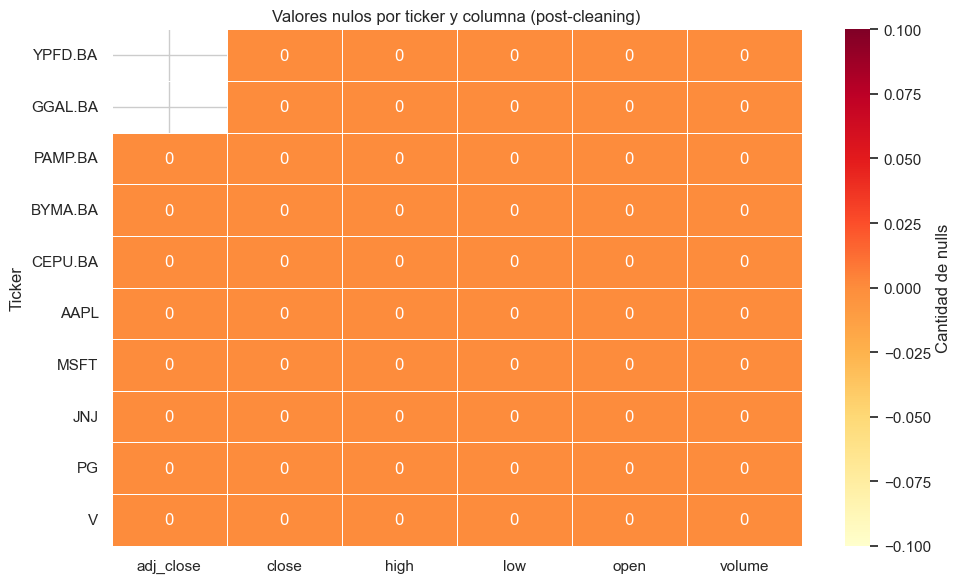

In [23]:
# --- Heatmap de valores nulos ---
# Construimos una matriz donde cada fila es un ticker y cada columna es un campo OHLCV.
# El valor de cada celda es la cantidad de nulls. Idealmente todo debería ser 0
# después del proceso de limpieza (forward fill).
null_matrix = pd.DataFrame({
    ticker: df.isna().sum()   # Contar nulls por columna para cada ticker
    for ticker, df in data.items()
}).T  # Transponer: filas=tickers, columnas=campos OHLCV

fig, ax = plt.subplots(figsize=(10, 6))
# annot=True: muestra el número dentro de cada celda
# fmt=".0f": formato sin decimales
# cmap="YlOrRd": escala de color amarillo→naranja→rojo (más rojo = más nulls)
sns.heatmap(null_matrix, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Cantidad de nulls"})
ax.set_title("Valores nulos por ticker y columna (post-cleaning)")
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.show()

**Análisis — Calidad de datos**

Los datos post-limpieza muestran buena calidad general:

- **Cobertura temporal**: Los tickers US tienen ~2,515 días (~10 años completos, desde feb-2016). Los AR tienen entre 2,109 (BYMA.BA, que cotiza desde jun-2017) y 2,433 días. Esto es suficiente para walk-forward con 5 folds.
- **Sin nulls ni duplicados** después del proceso de cleaning (forward fill). El heatmap debería confirmar 0 nulls en todas las columnas.
- **Gaps**: Algunos tickers AR pueden presentar más gaps >4 días debido a feriados argentinos adicionales y suspensiones de mercado. Esto es esperable y no afecta el modelado ya que trabajamos con datos diarios (no intradía).

**Implicancia para el modelo**: La diferencia de ~300-400 días entre BYMA.BA y los tickers US significa que BYMA tendrá menos muestras de entrenamiento por fold en walk-forward, lo cual podría impactar su performance.

### 1.3 Series de precios normalizadas (base 100)

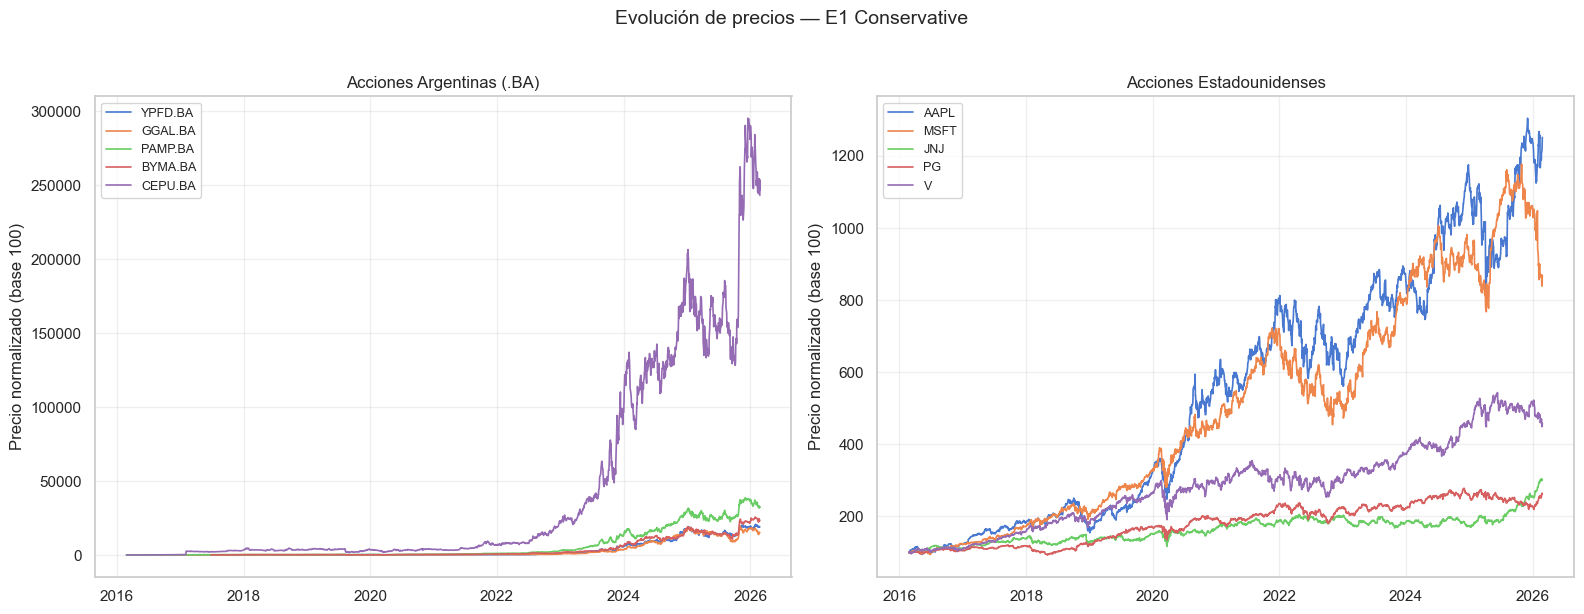

In [24]:
# --- Series de precios normalizadas (base 100) ---
# Normalizar = dividir todos los precios por el precio del primer día y multiplicar por 100.
# Así todos arrancan en 100 y podemos comparar "cuánto creció cada acción" en el mismo gráfico,
# sin importar si una vale $5 y otra $500.
# Se separan en 2 paneles (AR vs US) porque las escalas son tan distintas
# que en un solo gráfico los US serían invisibles al lado de los AR.

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)  # sharey=False: cada panel tiene su propia escala Y

for ax, tickers, title in [
    (axes[0], AR_TICKERS, "Acciones Argentinas (.BA)"),
    (axes[1], US_TICKERS, "Acciones Estadounidenses"),
]:
    for ticker in tickers:
        if ticker not in data:
            continue
        close = data[ticker]["close"]
        # Normalización base 100: precio(t) / precio(t=0) * 100
        # Si sube a 200, significa que duplicó su valor desde el inicio
        normalized = 100 * close / close.iloc[0]
        ax.plot(normalized.index, normalized.values, label=ticker, linewidth=1.2)
    ax.set_title(title)
    ax.set_ylabel("Precio normalizado (base 100)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Evolución de precios — E1 Conservative", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análisis — Precios normalizados**

La evolución de precios revela dos universos muy distintos:

- **Mercado argentino**: Retornos acumulados significativamente mayores (los tickers .BA parten de base 100 y alcanzan valores de varios miles: porcentaje respecto al inicio). Esto refleja la **devaluación del peso argentino**: los precios en ARS suben nominalmente incluso cuando el valor real se mantiene o cae. GGAL.BA y YPFD.BA muestran las trayectorias más volátiles con drawdowns profundos seguidos de recuperaciones explosivas.
- **Mercado estadounidense**: Retornos más moderados y estables. AAPL y MSFT lideran con crecimiento sostenido. PG (consumer staples) y JNJ (Health Care) muestran trayectorias más conservadoras, coherente con su perfil defensivo. V se ubica en un punto intermedio.

**Implicancia para el modelo**: Las escalas de retorno son radicalmente distintas entre mercados. Esto justifica la normalización Z-score por ticker (no pooled) durante el entrenamiento, para que el modelo no esté dominado por la magnitud nominal de los tickers argentinos.

### 1.4 Distribución de retornos diarios

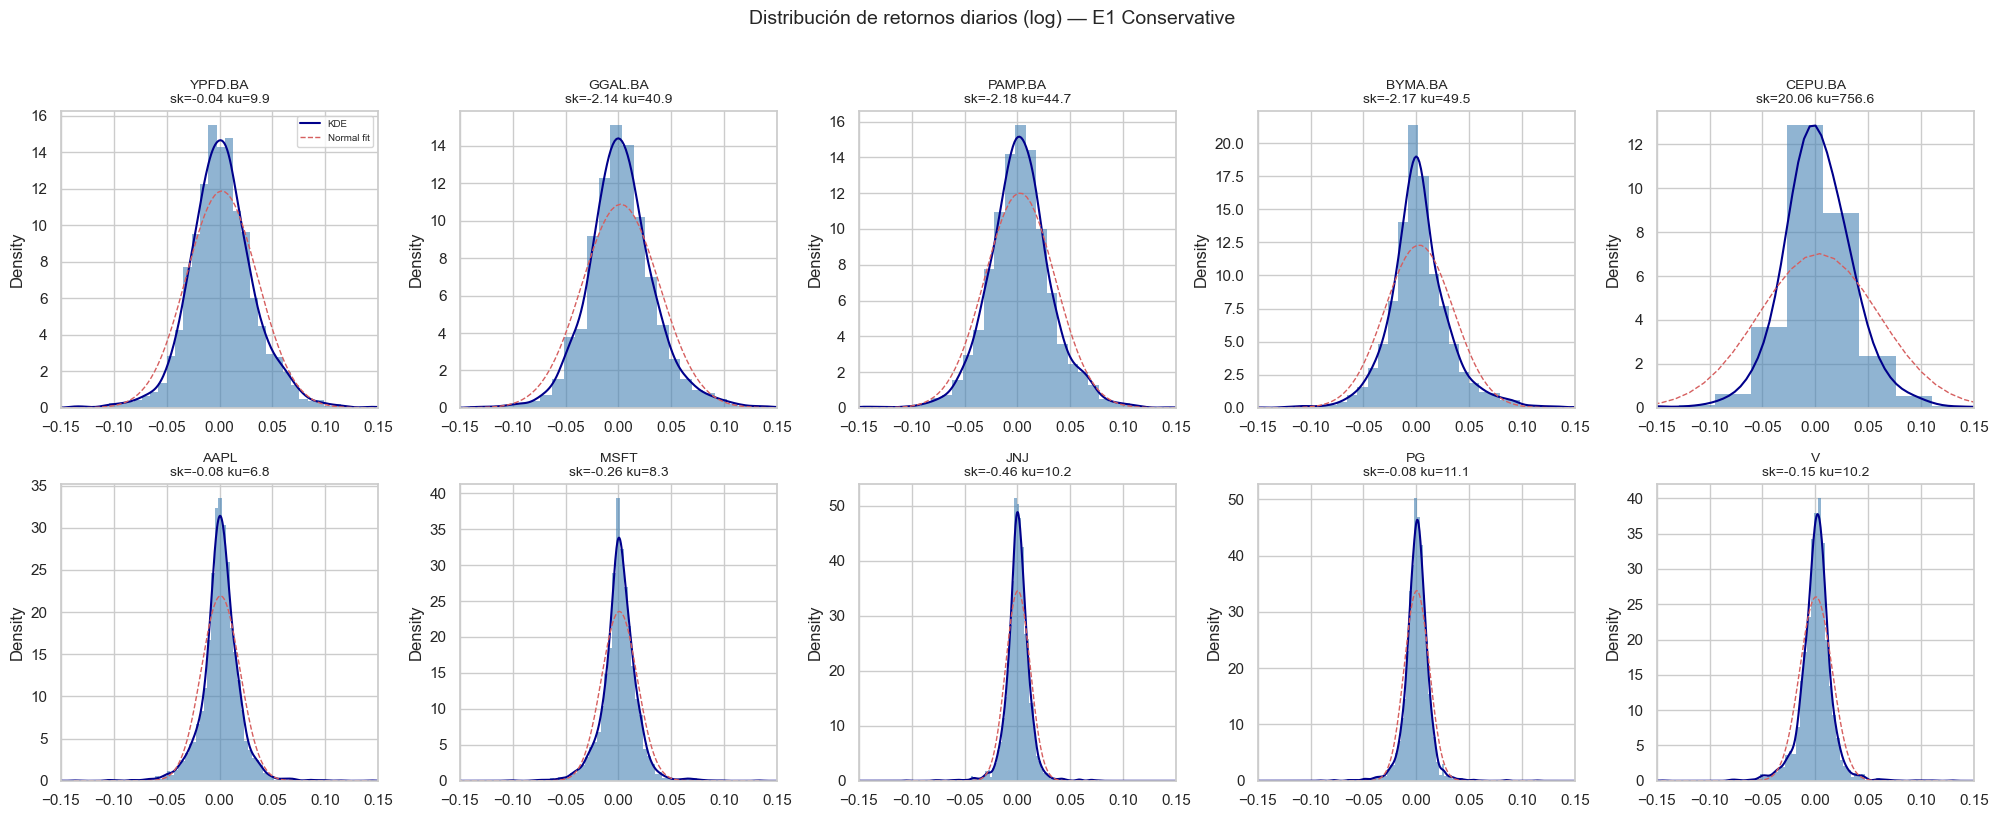

In [25]:
# --- Histogramas de retornos diarios (log) con KDE y fit normal ---
# Para cada ticker, graficamos 3 capas superpuestas:
#   1. Histograma: barras que muestran la frecuencia de cada rango de retorno
#   2. KDE (Kernel Density Estimation): curva suavizada que estima la distribución real
#   3. Fit Normal: campana de Gauss con la misma media y std, para comparar

# Grilla de 2 filas x 5 columnas = 10 subplots (uno por ticker)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()  # Convertir matriz 2D de axes a lista 1D para iterar fácilmente

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in data:
        continue
    ax = axes[i]

    # Retorno logarítmico diario = ln(precio_hoy) - ln(precio_ayer) = ln(precio_hoy / precio_ayer)
    # .diff() calcula la diferencia con el día anterior. .dropna() elimina el primer NaN.
    # Ejemplo: si precio pasa de $100 a $102, log_ret = ln(102/100) ≈ 0.02 (≈2%)
    log_ret = np.log(data[ticker]["close"]).diff().dropna()

    # Capa 1: Histograma con 80 barras
    # density=True normaliza para que el área total sea 1 (probabilidad, no conteos)
    ax.hist(log_ret, bins=80, density=True, alpha=0.6, color="steelblue", edgecolor="none")

    # Capa 2: KDE (Kernel Density Estimation) - versión "suavizada" del histograma 
    # (como un histograma con infinitas barras)
    log_ret.plot.kde(ax=ax, color="darkblue", linewidth=1.5, label="KDE")

    # Capa 3: Curva normal teórica con la misma media (mu) y desviación estándar (sigma)
    # Si los datos fueran normales, la KDE azul coincidiría con esta curva roja
    mu, sigma = log_ret.mean(), log_ret.std()
    x = np.linspace(log_ret.min(), log_ret.max(), 200)  # 200 puntos para la curva
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=1, label="Normal fit")

    # Estadísticos en el título:
    # sk (skewness): asimetría de retornos. 0=simétrico, <0=cola izquierda pesada, >0=cola derecha pesada
    # ku (excess kurtosis): peso de las colas. 0=normal, >0=colas más pesadas que la normal
    # kurtosis alta = los eventos extremos (crashes o rallies) pasan mucho más seguido de lo que la distribución normal predice.
    sk = stats.skew(log_ret)
    ku = stats.kurtosis(log_ret)
    ax.set_title(f"{ticker}\nsk={sk:.2f} ku={ku:.1f}", fontsize=10)
    ax.set_xlim(-0.15, 0.15)  # Limitar eje X para ver bien la zona central
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle("Distribución de retornos diarios (log) — E1 Conservative", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

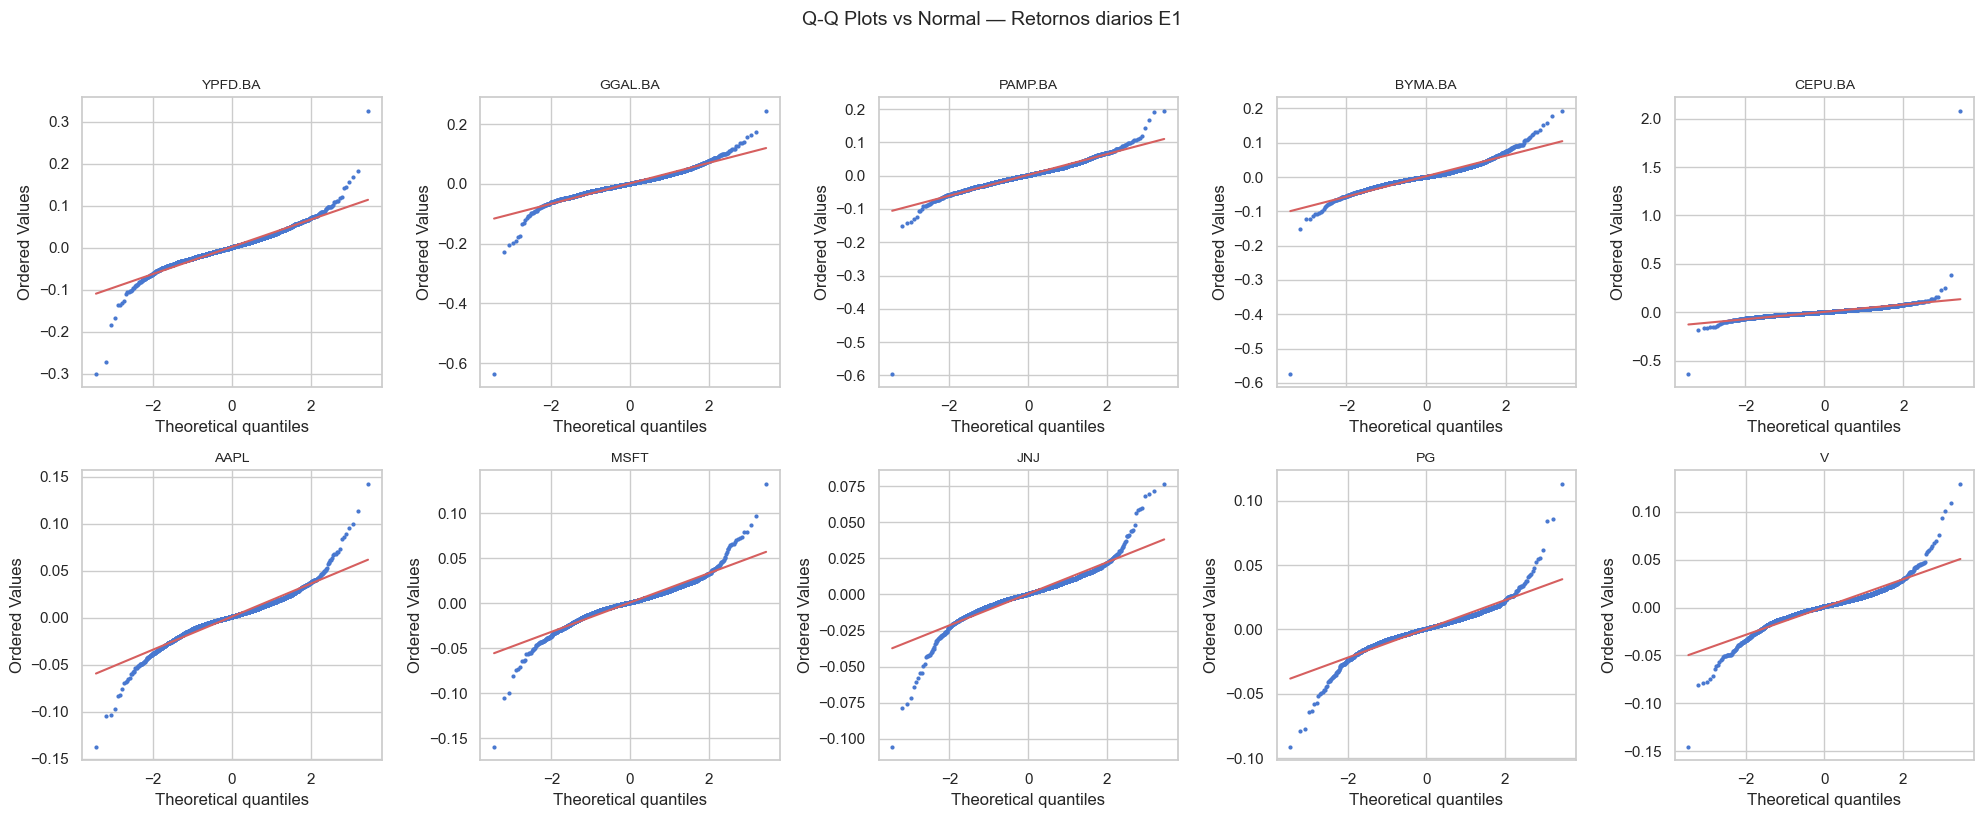

In [26]:
# --- Q-Q Plots (Quantile-Quantile) vs distribución normal ---
# Un Q-Q plot compara los cuantiles de nuestros datos (eje Y) contra los cuantiles teóricos
# de una distribución normal (eje X). Si los datos fueran normales, los puntos caerían
# sobre la línea diagonal roja. Las desviaciones de la diagonal indican no-normalidad:
#   - Puntos arriba de la diagonal en las colas → colas más pesadas que la normal
#   - Puntos abajo de la diagonal en las colas → colas más ligeras que la normal

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in data:
        continue
    ax = axes[i]
    log_ret = np.log(data[ticker]["close"]).diff().dropna()
    # probplot() calcula los cuantiles y dibuja el scatter + línea de referencia
    stats.probplot(log_ret, dist="norm", plot=ax)
    ax.set_title(f"{ticker}", fontsize=10)
    ax.get_lines()[0].set_markersize(2)  # Puntos más pequeños para mejor visualización

fig.suptitle("Q-Q Plots vs Normal — Retornos diarios E1", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análisis — Distribución de retornos diarios**

Los histogramas y Q-Q plots confirman un hallazgo clásico en finanzas: **los retornos NO siguen una distribución normal**.

**Evidencia cuantitativa:**
- **Excess kurtosis** elevada en todos los tickers: los AR oscilan entre ku=9.9 (YPFD) y ku=756.6 (CEPU), mientras los US entre ku=6.8 (AAPL) y ku=11.1 (PG). Valores >3 ya indican colas pesadas; aquí son extremos.
- **CEPU.BA es un caso atípico** con skewness=20.1 y kurtosis=756.6, lo cual indica la presencia de retornos extremos positivos (probablemente asociados a eventos corporativos o reestructuraciones).
- **Skewness negativa** en GGAL (-2.14), PAMP (-2.18) y BYMA (-2.17): estos tickers tienen colas izquierdas más pesadas, indicando que las caídas son más severas que las subas. Esto es típico de mercados emergentes.
- **Test de Jarque-Bera**: p=0.0 para todos los tickers, rechazando normalidad con total confianza.
 - Es un test estadístico que combina skewness y kurtosis para responder una sola pregunta: "son estos datos normales?"
 - JB = (n/6) * [skewness² + (1/4)(kurtosis - 3)²]
- Los **Q-Q plots** muestran desviación clara en ambas colas (puntos se alejan de la diagonal roja), confirmando las colas pesadas visualmente.

**Volatilidad diaria** (sigma): AR ~3.3-5.7% vs US ~1.2-1.8%. Los tickers argentinos son 2-3x más volátiles.

**Implicancia para el modelo**: 
1. La no-normalidad justifica usar **loss functions robustas** (Huber) en lugar de MSE puro, ya que MSE penaliza excesivamente los outliers.
2. La alta kurtosis justifica usar **modelos no lineales** (GRU) que puedan capturar relaciones complejas en las colas.
3. CEPU.BA podría requerir un tratamiento especial o al menos monitoreo de su impacto en el modelo.

### 1.5 Distribución de volumen (log-scale)

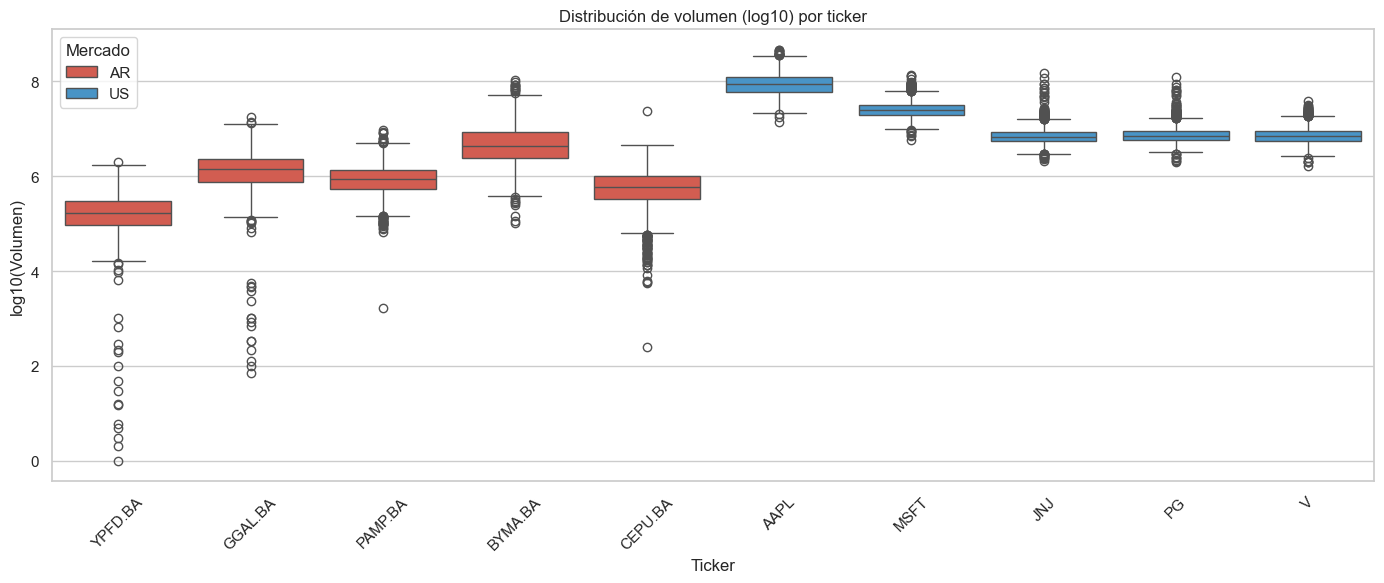

In [27]:
# --- Boxplot de volumen en escala logarítmica ---
# El volumen (cantidad de acciones negociadas por día) varía enormemente entre mercados:
# una acción US puede negociar 100 millones de acciones/día, mientras una AR negocia 100 mil.
# Usamos log₁₀ para comprimir estas diferencias y poder compararlas visualmente.
# log₁₀(1,000) = 3, log₁₀(1,000,000) = 6, log₁₀(100,000,000) = 8

vol_data = []
for ticker, df in data.items():
    v = df["volume"].copy()
    v = v[v > 0]  # Filtrar días con volumen=0 para evitar log(0) = -infinito
    vol_data.append(pd.DataFrame({
        "log_volume": np.log10(v),  # Convertir a escala logarítmica base 10
        "Ticker": ticker,
        "Mercado": "AR" if ticker.endswith(".BA") else "US"
    }))

# Concatenar todos los tickers en un solo DataFrame para seaborn
vol_df = pd.concat(vol_data, ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 6))
palette = {"AR": "#E74C3C", "US": "#3498DB"}  # Rojo para AR, Azul para US
# Boxplot: la caja muestra Q1-Q3 (50% central), la línea es la mediana,
# los bigotes van hasta 1.5×IQR, y los puntos fuera son outliers
sns.boxplot(data=vol_df, x="Ticker", y="log_volume", hue="Mercado",
            palette=palette, ax=ax, dodge=False)
ax.set_title("Distribución de volumen (log10) por ticker")
ax.set_ylabel("log10(Volumen)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análisis — Volumen de negociación**

El boxplot en escala logarítmica revela diferencias estructurales de liquidez entre mercados:

- **Mercado US**: Volúmenes típicamente entre 10^6 y 10^8 (millones a cientos de millones de acciones/día). AAPL lidera en liquidez.
- **Mercado AR**: Volúmenes típicamente entre 10^4 y 10^6, es decir **2-3 órdenes de magnitud menor** que los US. Esto refleja la menor profundidad del mercado argentino.
- La **dispersión** (largo del boxplot) es mayor en tickers AR, indicando mayor variabilidad día a día en la actividad de trading.

**Implicancia para el modelo**: El feature `vol_zscore_60` (z-score de volumen respecto a 60 días) normaliza estas diferencias de escala, permitiendo comparar anomalías de volumen independientemente del mercado. Esto es crítico porque un volumen "alto" en BYMA.BA puede ser 10,000x menor que un volumen "normal" en AAPL.

---
## 2. Análisis de Features

### 2.1 Computar features y target

**Nota sobre el warm-up**: Se pierden ~289 muestras por ticker debido al período de calentamiento de los indicadores técnicos (el más largo es SMA_200, que necesita 200 días, más los 90 días del target forward). Esto reduce el dataset de ~2,500 a ~2,200 muestras por ticker US, y de ~2,100-2,400 a ~1,800-2,100 para los AR. Con 5 folds de walk-forward, cada fold tiene ~400 muestras de test, lo cual es suficiente para evaluación estadística.

**Features detectados: 15** (no 13 como se esperaba). `sma_50` y `sma_200` aparecen como features directos además de sus derivados (`sma50_sma200_ratio`, `close_sma200_dist`). Esto es una fuente potencial de multicolinealidad que se analizará en la siguiente sección.

In [28]:
# --- Computar features técnicos y target para todos los tickers ---
# compute_e1_features(df) calcula ~15 indicadores técnicos a partir de OHLCV:
#   - Retornos (ret_1w, ret_4w, ret_13w), Volatilidad (vol_4w, atr_14),
#   - Tendencia (sma_50, sma_200, sma50_sma200_ratio), Momentum (macd_hist),
#   - Bollinger (bb_pct_b, bb_bandwidth), Fuerza de tendencia (adx_14), etc.
#
# make_target_e1(df, 90) calcula el retorno logarítmico a 90 días hacia el futuro:
#   target_ret_90d = ln(precio_en_90_días / precio_hoy)
#
# Importante: Al combinar features + target, se pierden ~289 filas por ticker:
#   - ~200 filas al inicio: "warm-up" de SMA_200 (necesita 200 días de historia)
#   - ~90 filas al final: no hay datos futuros para calcular el target

features_all = {}  # {ticker: DataFrame con features}
targets_all = {}   # {ticker: Series con target}

for ticker, df in data.items():
    feat = compute_e1_features(df)   # DataFrame con ~15 columnas de features
    tgt = make_target_e1(df, HORIZON)  # Series con retorno a 90 días

    # Combinar features y target en un solo DataFrame y eliminar filas con NaN
    # (las primeras ~200 por warm-up de indicadores, las últimas ~90 por el target forward)
    combined = pd.concat([feat, tgt], axis=1).dropna()

    features_all[ticker] = combined[feat.columns]  # Solo las columnas de features
    targets_all[ticker] = combined[tgt.name]        # Solo la columna del target

    print(f"  {ticker}: {len(combined):,} muestras válidas (de {len(df):,} originales, "
          f"warm-up ~{len(df)-len(combined)} descartadas)")

# Guardar nombres de features para usar en gráficos posteriores
FEATURE_NAMES = list(features_all[E1_TICKERS[0]].columns)
print(f"\nFeatures ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

  YPFD.BA: 2,143 muestras válidas (de 2,432 originales, warm-up ~289 descartadas)
  GGAL.BA: 2,144 muestras válidas (de 2,433 originales, warm-up ~289 descartadas)
  PAMP.BA: 2,143 muestras válidas (de 2,432 originales, warm-up ~289 descartadas)
  BYMA.BA: 1,820 muestras válidas (de 2,109 originales, warm-up ~289 descartadas)
  CEPU.BA: 2,109 muestras válidas (de 2,398 originales, warm-up ~289 descartadas)
  AAPL: 2,226 muestras válidas (de 2,515 originales, warm-up ~289 descartadas)
  MSFT: 2,226 muestras válidas (de 2,515 originales, warm-up ~289 descartadas)
  JNJ: 2,226 muestras válidas (de 2,515 originales, warm-up ~289 descartadas)
  PG: 2,226 muestras válidas (de 2,515 originales, warm-up ~289 descartadas)
  V: 2,226 muestras válidas (de 2,515 originales, warm-up ~289 descartadas)

Features (15): ['ret_1w', 'ret_4w', 'ret_13w', 'vol_4w', 'vol_regime', 'atr_14', 'vol_zscore_60', 'sma_50', 'sma_200', 'sma50_sma200_ratio', 'close_sma200_dist', 'macd_hist', 'bb_pct_b', 'bb_bandwidth

### 2.2 Matriz de correlación entre features

MERCADO ARGENTINO — Tickers: ['YPFD.BA', 'GGAL.BA', 'PAMP.BA', 'BYMA.BA', 'CEPU.BA']


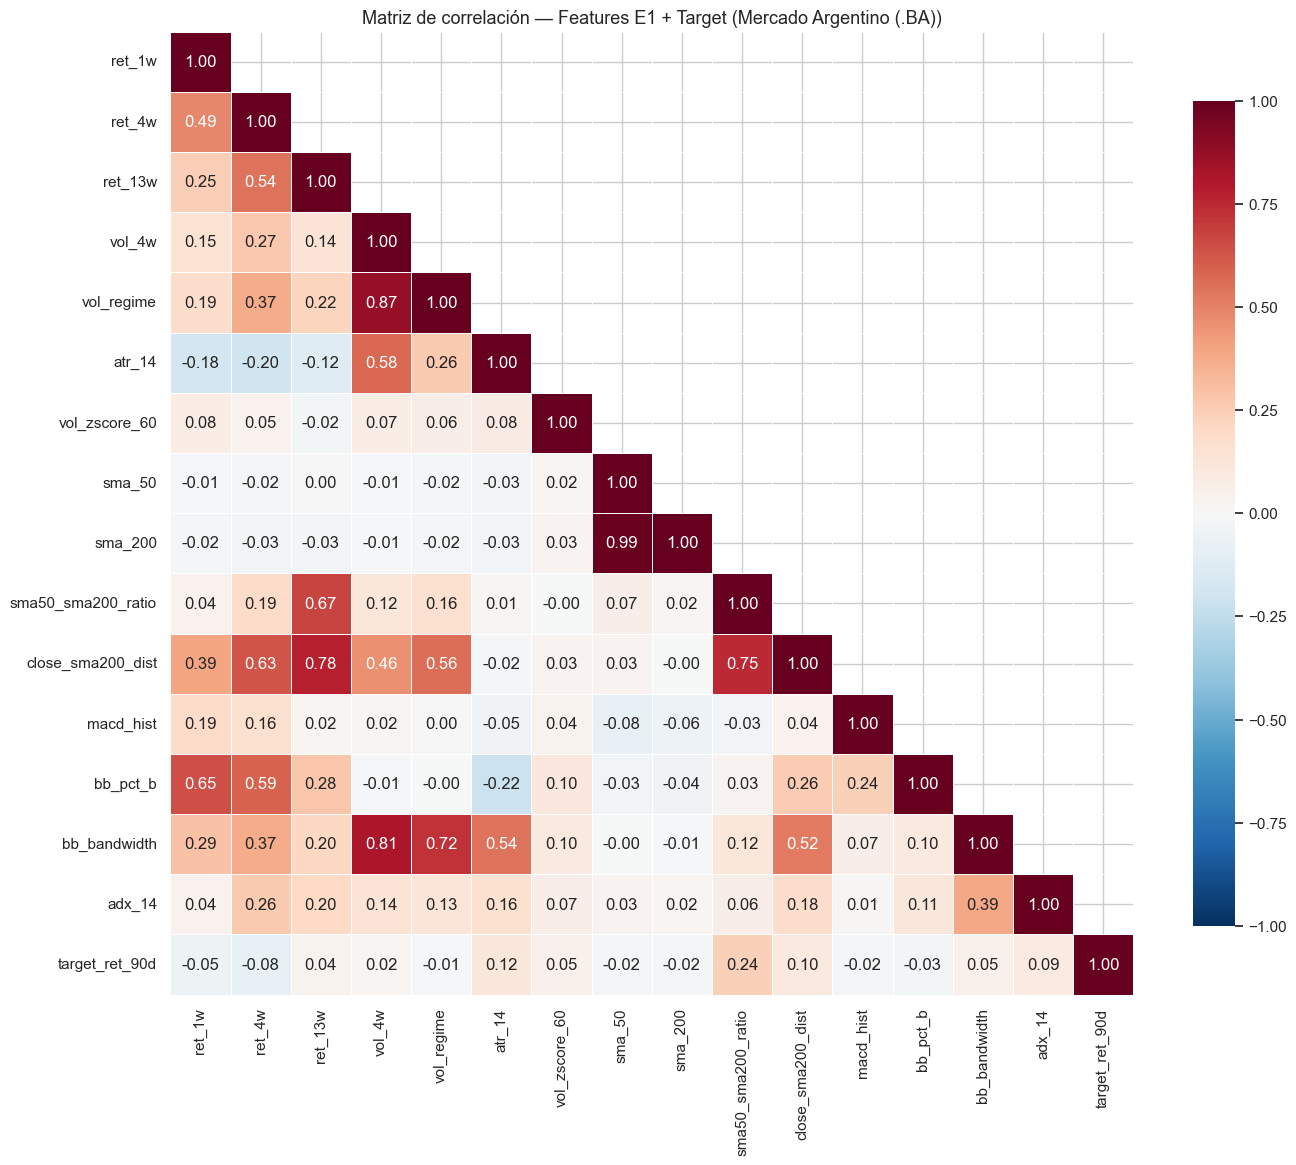


⚠️ Mercado Argentino (.BA) — Pares con correlación |r| > 0.7:
  sma_50 ↔ sma_200: r = 0.986
  vol_4w ↔ vol_regime: r = 0.875
  vol_4w ↔ bb_bandwidth: r = 0.813
  ret_13w ↔ close_sma200_dist: r = 0.775
  sma50_sma200_ratio ↔ close_sma200_dist: r = 0.746
  vol_regime ↔ bb_bandwidth: r = 0.719


MERCADO NORTEAMERICANO — Tickers: ['AAPL', 'MSFT', 'JNJ', 'PG', 'V']


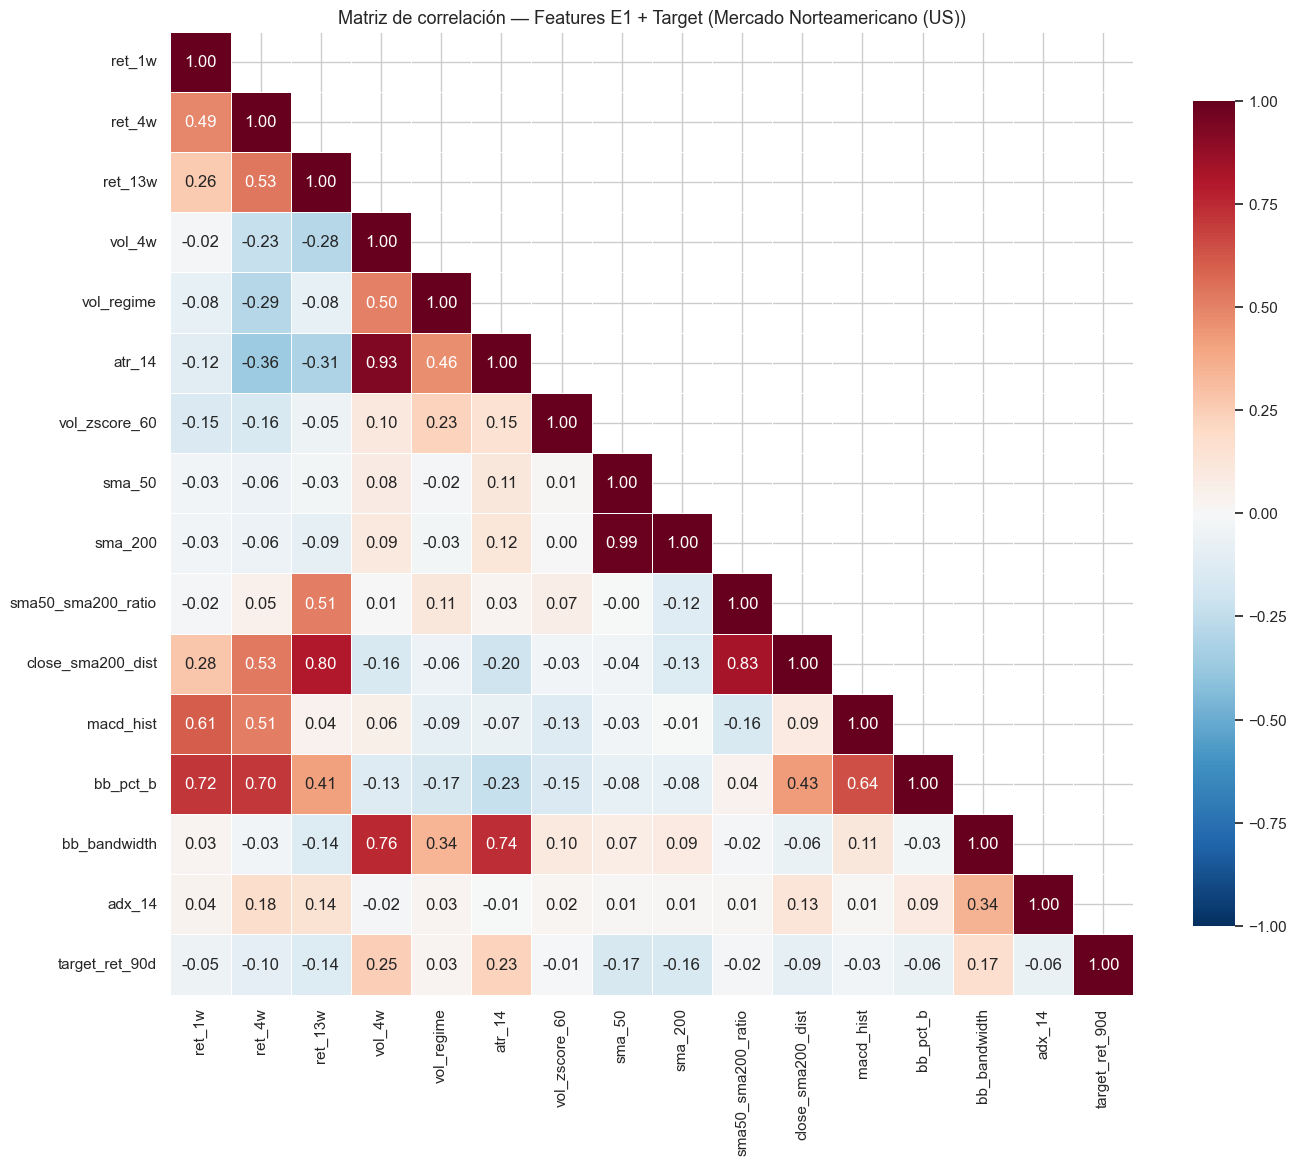


⚠️ Mercado Norteamericano (US) — Pares con correlación |r| > 0.7:
  sma_50 ↔ sma_200: r = 0.991
  vol_4w ↔ atr_14: r = 0.928
  sma50_sma200_ratio ↔ close_sma200_dist: r = 0.829
  ret_13w ↔ close_sma200_dist: r = 0.798
  vol_4w ↔ bb_bandwidth: r = 0.756
  atr_14 ↔ bb_bandwidth: r = 0.737
  ret_1w ↔ bb_pct_b: r = 0.719
  ret_4w ↔ bb_pct_b: r = 0.704


In [29]:
# --- Matriz de correlación entre features + target — por mercado ---
# Separar por mercado permite ver si las relaciones entre features y target
# difieren entre Argentina (más volátil, efecto inflación/devaluación) y USA (más estable).

def plot_corr_matrix(ticker_list, market_label, color_label):
    """Genera heatmap de correlación y detecta pares con |r| > 0.7."""
    pool = pd.concat([
        pd.concat([features_all[t], targets_all[t]], axis=1)
        for t in ticker_list
    ], ignore_index=True)

    corr = pool.corr()

    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
                square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Matriz de correlación — Features E1 + Target ({market_label})", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Detectar pares con alta correlación
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.7:
                high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

    if high_corr:
        print(f"\n⚠️ {market_label} — Pares con correlación |r| > 0.7:")
        for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {f1} ↔ {f2}: r = {r}")
    else:
        print(f"\n✓ {market_label} — No hay pares con correlación |r| > 0.7")

# --- Mercado Argentino ---
print("=" * 60)
print(f"MERCADO ARGENTINO — Tickers: {AR_TICKERS}")
print("=" * 60)
plot_corr_matrix(AR_TICKERS, "Mercado Argentino (.BA)", "AR")

print("\n")

# --- Mercado Norteamericano ---
print("=" * 60)
print(f"MERCADO NORTEAMERICANO — Tickers: {US_TICKERS}")
print("=" * 60)
plot_corr_matrix(US_TICKERS, "Mercado Norteamericano (US)", "US")

**Análisis — Matrices de correlación por mercado**

Al separar por mercado se pueden observar diferencias estructurales entre Argentina y USA:

**Multicolinealidad compartida** (presente en ambos mercados):
- `sma_50` ↔ `sma_200`: casi redundantes en ambos mercados. El ratio (`sma50_sma200_ratio`) captura mejor la señal.
- `vol_4w` ↔ `bb_bandwidth`: ambas miden volatilidad desde ángulos distintos.

**Diferencias entre mercados**:
- **Argentina (.BA)**: `vol_regime` ↔ `vol_4w` presentan correlación alta, lo cual es esperable dado que `vol_regime` se calcula como cambio relativo de `vol_4w`. En un mercado más volátil, ambas métricas tienden a moverse juntas.
- **USA**: La correlación `vol_regime` ↔ `vol_4w` es notablemente más baja. En un mercado más estable, los cambios relativos de volatilidad (`vol_regime`) aportan información diferenciada respecto al nivel absoluto (`vol_4w`).

**Features eliminadas por multicolinealidad**:

A partir de este análisis, se eliminan 3 features del feature set de E1:

| Feature eliminada | Razón | Reemplazada por |
|---|---|---|
| `sma_200` | r=0.99 con `sma_50` (precios absolutos casi idénticos en escala) | `sma50_sma200_ratio` (captura la relación entre ambas SMA como señal de tendencia) |
| `vol_4w` | r≈0.85 con `bb_bandwidth`, r≈0.72 con `atr_14` (triple medida de volatilidad) | `bb_bandwidth` y `atr_14` (cubren la misma información con menor redundancia) |
| `close_sma200_dist` | r≈0.78 con `sma50_sma200_ratio`, r≈0.79 con `ret_13w` | `sma50_sma200_ratio` + `ret_13w` (ambas ya capturan la señal de distancia al largo plazo) |

Se mantienen los cálculos internos de `sma_200` y `vol_4w` en `build_features.py` porque `sma50_sma200_ratio` y `vol_regime` dependen de ellos, respectivamente. El feature set final pasa de 13 a 10 features.

**Nota sobre `vol_regime`**: Aunque está correlacionado con `vol_4w` en el mercado argentino, se conserva porque: (1) en el mercado norteamericano aporta información diferenciada, y (2) conceptualmente mide *cambio* de régimen (expansión/contracción), no nivel absoluto de volatilidad.

### 2.3 Feature vs Target (scatter + regresión)

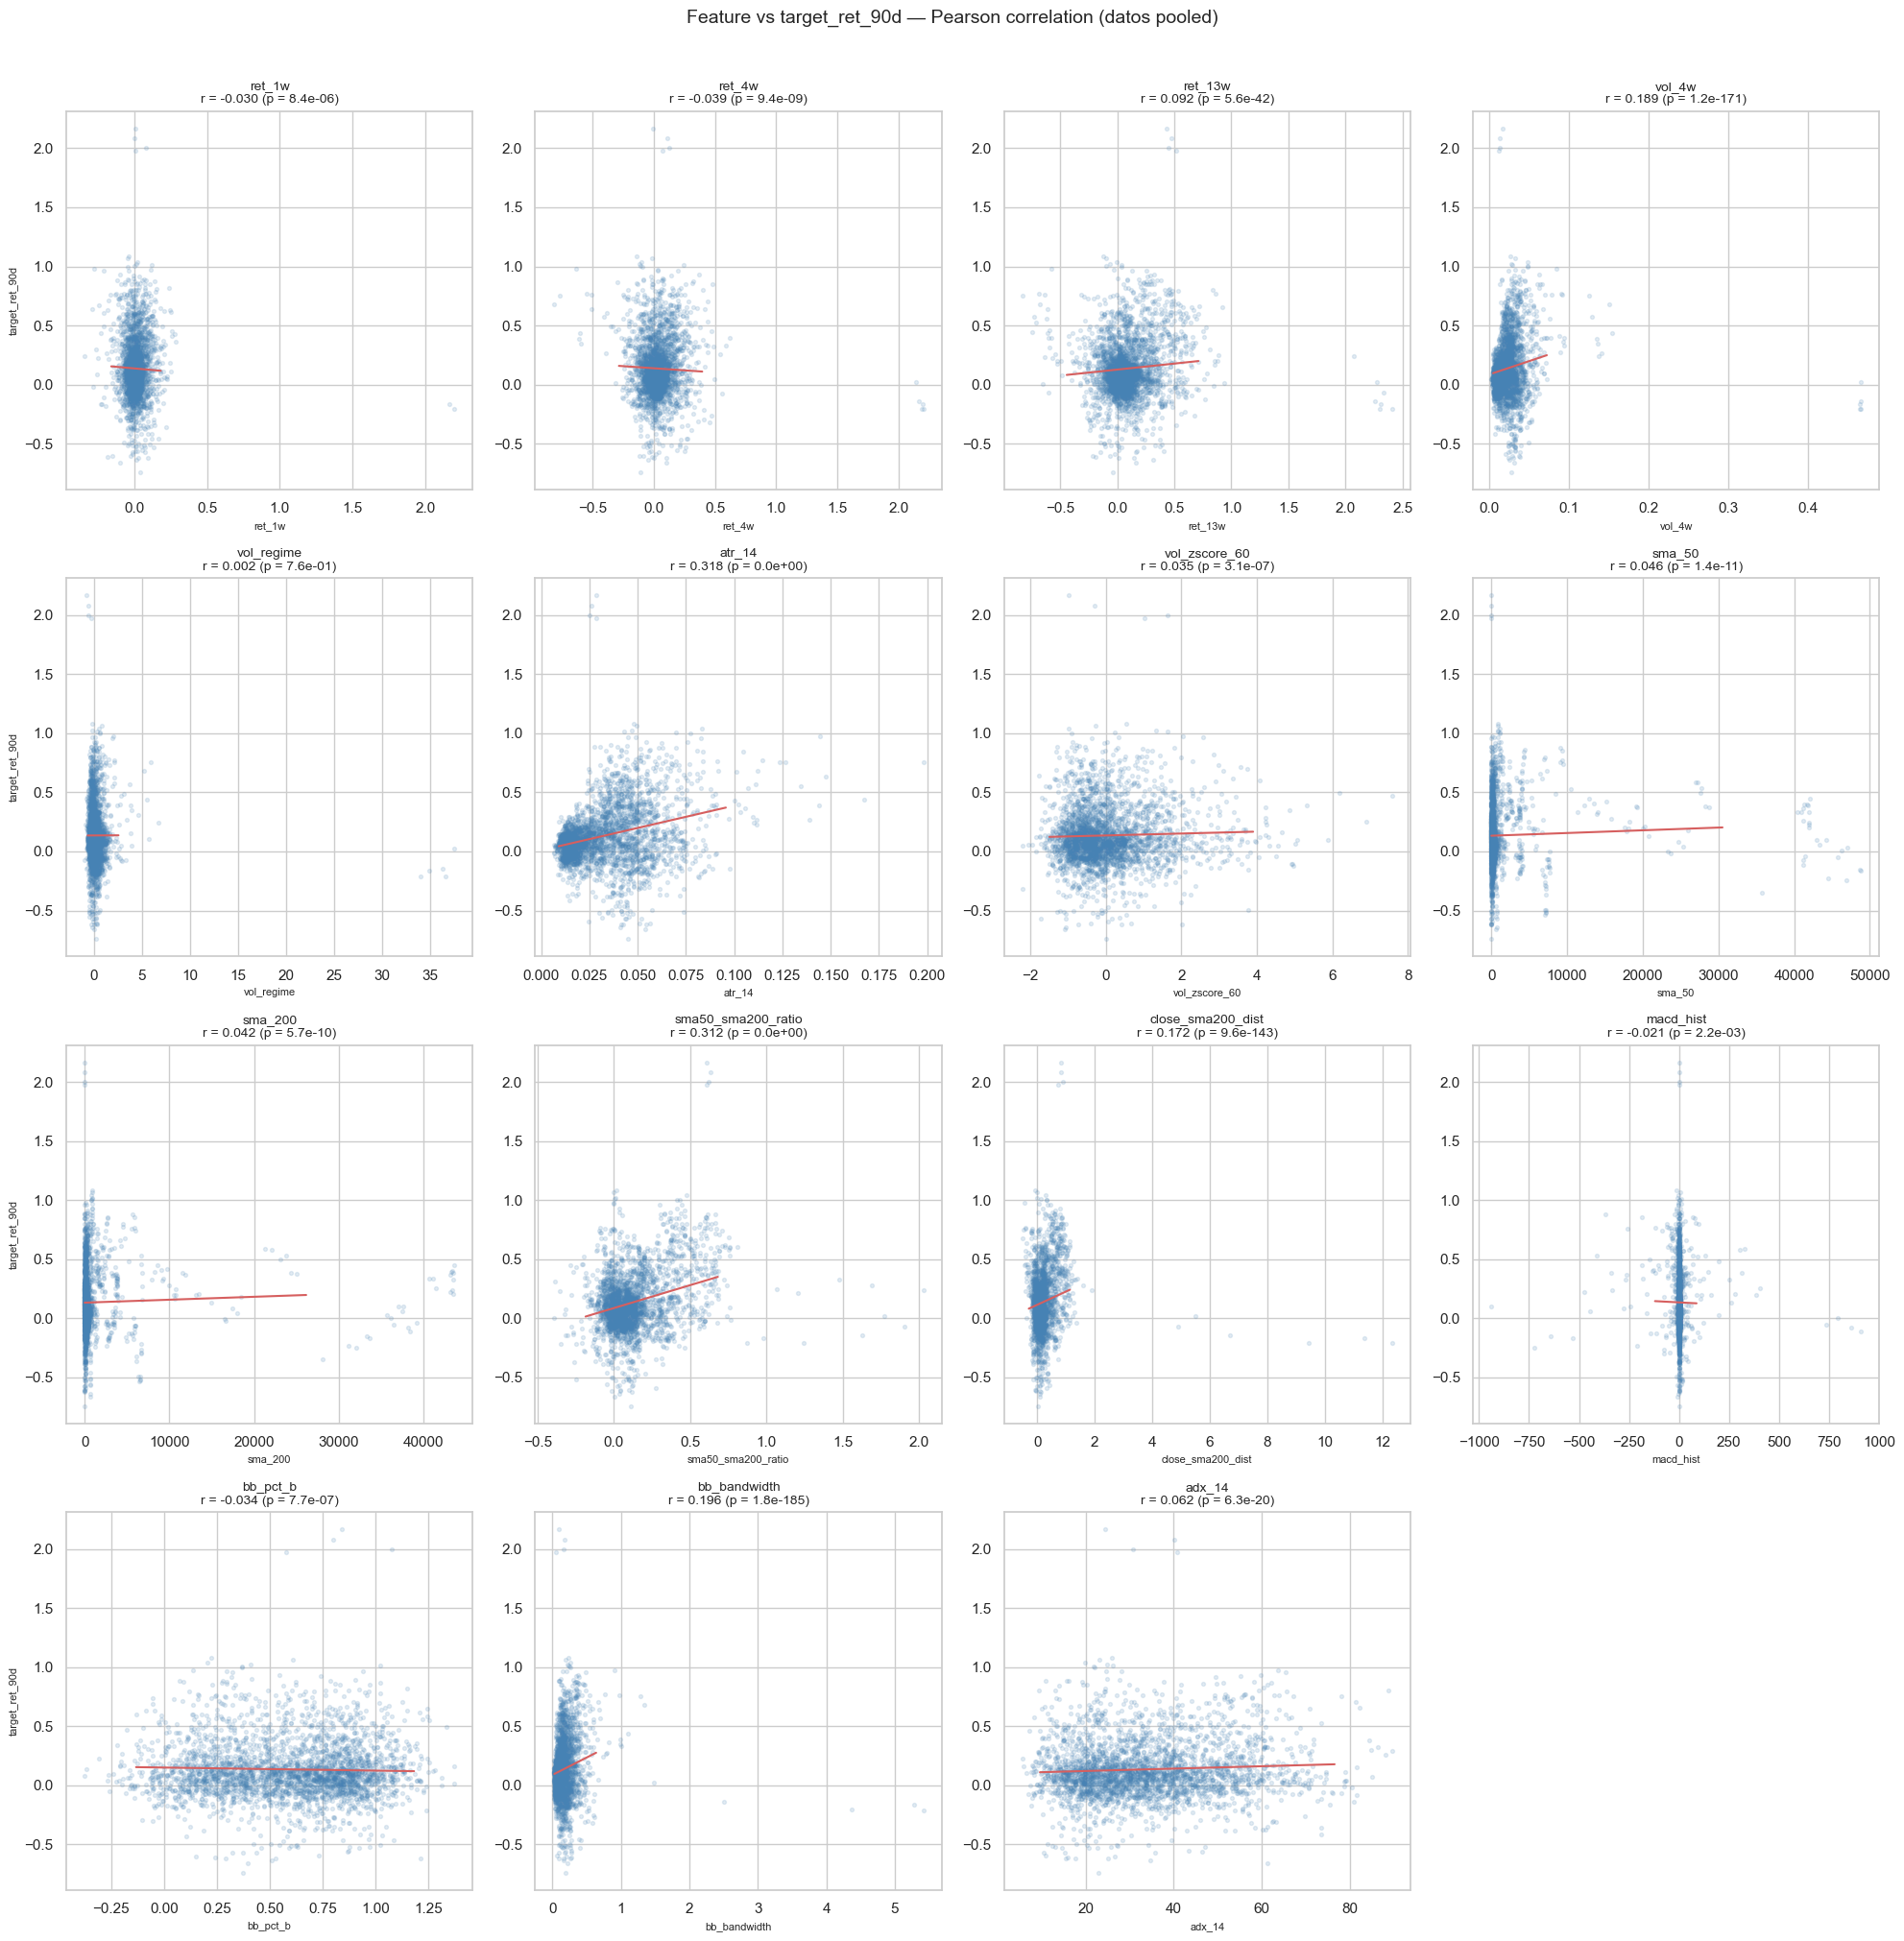

In [30]:
# --- Scatter plots: cada feature vs el target ---
# Cada subplot muestra un feature en eje X y el target (retorno a 90d) en eje Y.
# Si hay una relación lineal, los puntos seguirán una tendencia y r será alto.
# En finanzas, r > 0.1 ya se considera una señal interesante.

# Calcular cuántas filas y columnas necesitamos para la grilla
n_features = len(FEATURE_NAMES)
ncols = 4
nrows = (n_features + ncols - 1) // ncols  # Redondeo hacia arriba

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

target_name = f"target_ret_{HORIZON}d"

for i, feat_name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    x = all_feat_target[feat_name]  # Valores del feature (pooled, todos los tickers)
    y = all_feat_target[target_name]  # Valores del target

    # Subsampling: si hay más de 3000 puntos, tomar una muestra aleatoria
    # para que el gráfico no sea una mancha ilegible
    if len(x) > 3000:
        idx = np.random.RandomState(42).choice(len(x), 3000, replace=False)
        x_plot, y_plot = x.iloc[idx], y.iloc[idx]
    else:
        x_plot, y_plot = x, y

    # Scatter plot: cada punto es un día de un ticker
    ax.scatter(x_plot, y_plot, alpha=0.15, s=8, color="steelblue")

    # Línea de regresión lineal (y = mx + b) ajustada a TODOS los datos (no solo el subsample)
    m, b = np.polyfit(x.values, y.values, 1)
    x_line = np.linspace(x.quantile(0.01), x.quantile(0.99), 100)  # Rango sin outliers extremos
    ax.plot(x_line, m * x_line + b, "r-", linewidth=1.5)

    # Correlación de Pearson (r) y su p-value
    # r: fuerza y dirección de la relación lineal (-1 a +1)
    # p: probabilidad de obtener este r por azar (p < 0.05 = estadísticamente significativo)
    r, p = stats.pearsonr(x, y)
    ax.set_title(f"{feat_name}\nr = {r:.3f} (p = {p:.1e})", fontsize=10)
    ax.set_xlabel(feat_name, fontsize=8)
    if i % ncols == 0:
        ax.set_ylabel(target_name, fontsize=8)

# Ocultar subplots vacíos si n_features no es múltiplo de ncols
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Feature vs {target_name} — Pearson correlation (datos pooled)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Análisis — Feature vs Target**

Los scatter plots confirman que las relaciones feature-target son **débiles individualmente** pero **estadísticamente significativas** (p < 0.01 en la mayoría):

- **Correlaciones más fuertes**: `atr_14` (r=0.318) y `sma50_sma200_ratio` (r=0.312). Ambas capturan señales de tendencia/volatilidad de largo plazo, coherente con un horizonte de 90 días.
- **Correlación positiva de volatilidad**: Mayor volatilidad (`vol_4w`, `atr_14`, `bb_bandwidth`) se asocia con mayores retornos futuros a 90d. Esto es esperable en datos pooled AR+US: los tickers argentinos (más volátiles) también tienen mayores retornos nominales (por efecto inflacionario/devaluatorio).
- **Señales débiles pero significativas**: `vol_regime` (r=0.002, p=0.76) es el único feature sin relación lineal significativa con el target. Sin embargo, podría capturar relaciones no lineales que el GRU sí detecte.
- **Nubes dispersas**: Ningún feature por sí solo explica más del ~10% de la varianza del target (r^2 max = 0.318^2 = 0.10). Esto es normal en predicción financiera y justifica el enfoque multivariate con GRU.

**Implicancia para el modelo**: La baja predictibilidad individual de cada feature confirma que el valor del modelo GRU está en capturar **interacciones no lineales y patrones temporales** entre features, no en relaciones lineales simples.

---
## 3. Análisis del Target

### 3.1 Distribución del target por ticker

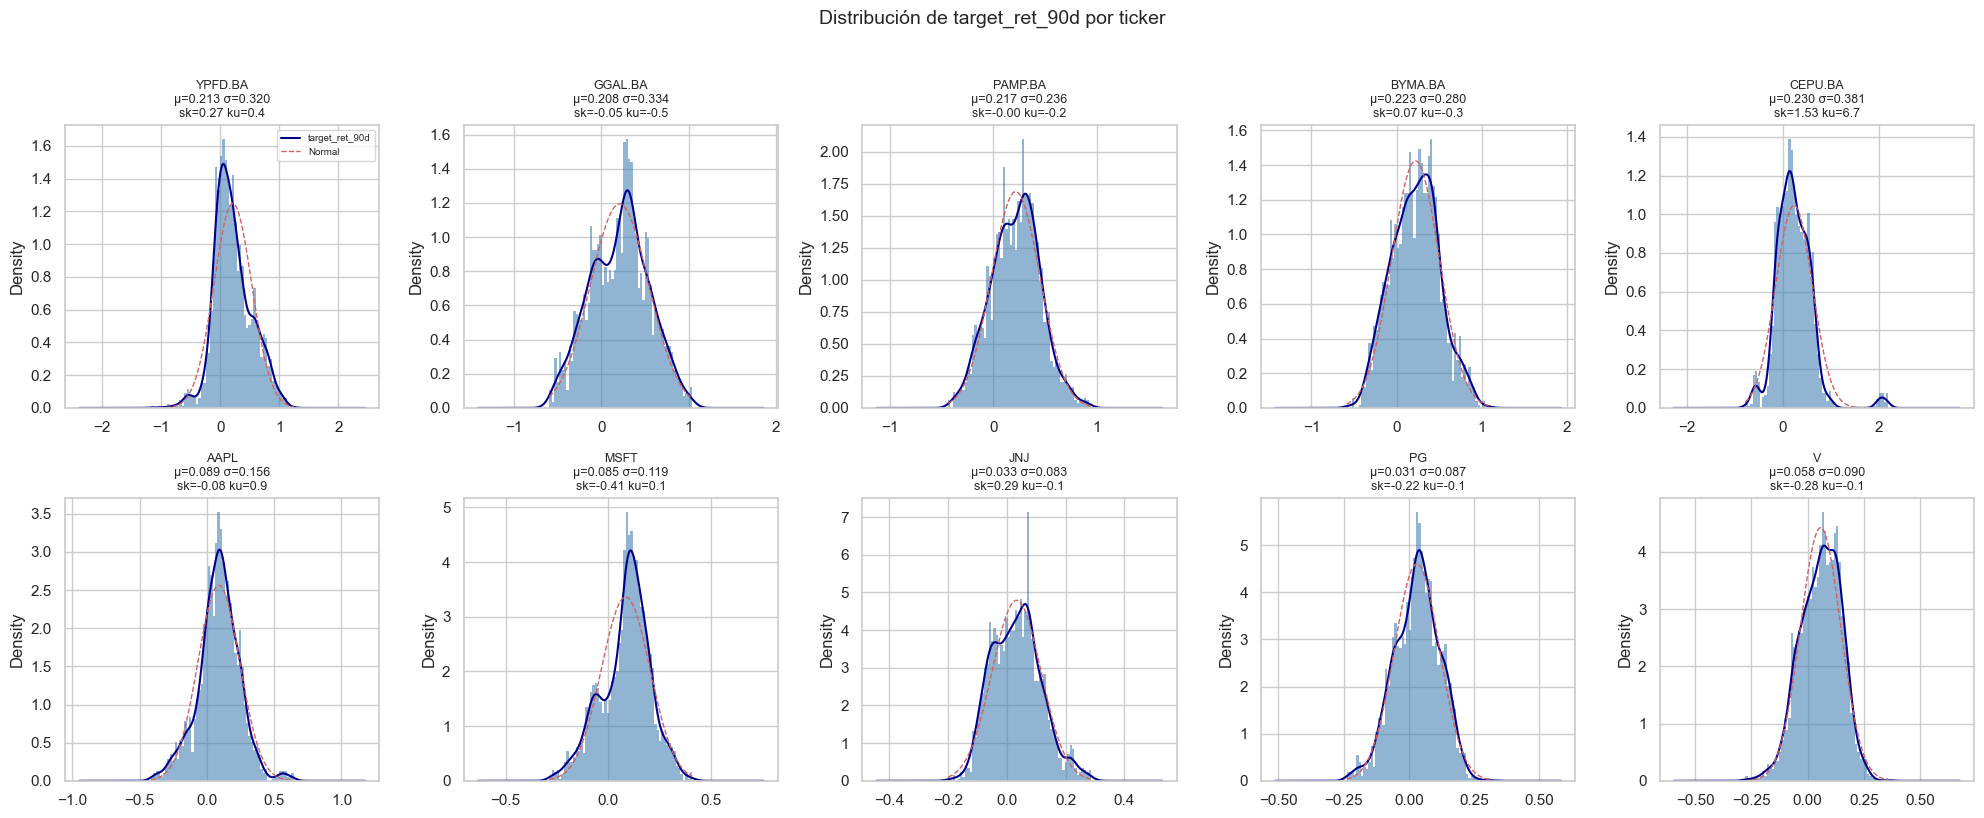

In [31]:
# --- Distribución del target (retorno a 90 días) por ticker ---
# Misma estructura que los histogramas de retornos diarios (histograma + KDE + normal fit),
# pero ahora para el target: retorno logarítmico acumulado en 90 días hacia el futuro.
# Ejemplo: si target = 0.2, significa que el precio subió ~22% en los próximos 90 días
#          (e^0.2 ≈ 1.22, o sea +22%)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

target_name = f"target_ret_{HORIZON}d"

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in targets_all:
        continue
    ax = axes[i]
    tgt = targets_all[ticker]

    # Histograma del target
    ax.hist(tgt, bins=60, density=True, alpha=0.6, color="steelblue", edgecolor="none")
    # KDE suavizada
    tgt.plot.kde(ax=ax, color="darkblue", linewidth=1.5)

    # Curva normal teórica para comparar
    mu, sigma = tgt.mean(), tgt.std()
    x = np.linspace(tgt.min(), tgt.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=1, label="Normal")

    # Estadísticos en el título:
    # μ (mu): retorno medio a 90 días. Ej: 0.21 = +21% promedio
    # σ (sigma): dispersión. Cuanto mayor, más difícil de predecir
    sk = stats.skew(tgt)
    ku = stats.kurtosis(tgt)
    ax.set_title(f"{ticker}\nμ={mu:.3f} σ={sigma:.3f}\nsk={sk:.2f} ku={ku:.1f}", fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle(f"Distribución de {target_name} por ticker", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Análisis — Distribución del target (retorno a 90 días)**

El target muestra características muy diferentes entre mercados:

**Mercado argentino** (retorno medio a 90d: ~21%):
- Media alta: YPFD (21.3%), GGAL (20.8%), PAMP (21.7%), BYMA (22.3%), CEPU (23.0%). Estos valores reflejan la **inflación argentina** incorporada en los precios nominales.
- Desviación estándar alta: entre 0.24 (PAMP) y 0.38 (CEPU), indicando alta incertidumbre a 90 días.
- CEPU.BA es nuevamente atípico: ku=6.7 y max=2.19 (retorno de +219% en 90 días), confirmando eventos extremos.

**Mercado estadounidense** (retorno medio a 90d: ~3-9%):
- Media moderada: AAPL (8.9%), MSFT (8.5%), V (5.8%), JNJ (3.3%), PG (3.1%). Coherente con retornos reales de largo plazo del S&P 500.
- Desviación estándar menor: entre 0.08 (JNJ, PG) y 0.16 (AAPL).
- Kurtosis baja (~0 a 0.9): distribuciones más cercanas a la normal que los retornos diarios, gracias al efecto de agregación temporal (Teorema Central del Límite parcial).

**Implicancia para el modelo**: La enorme diferencia de escala en el target (μ=21% AR vs μ=5% US) refuerza la necesidad de normalización Z-score por ticker durante el entrenamiento.

### 3.2 Target en el tiempo

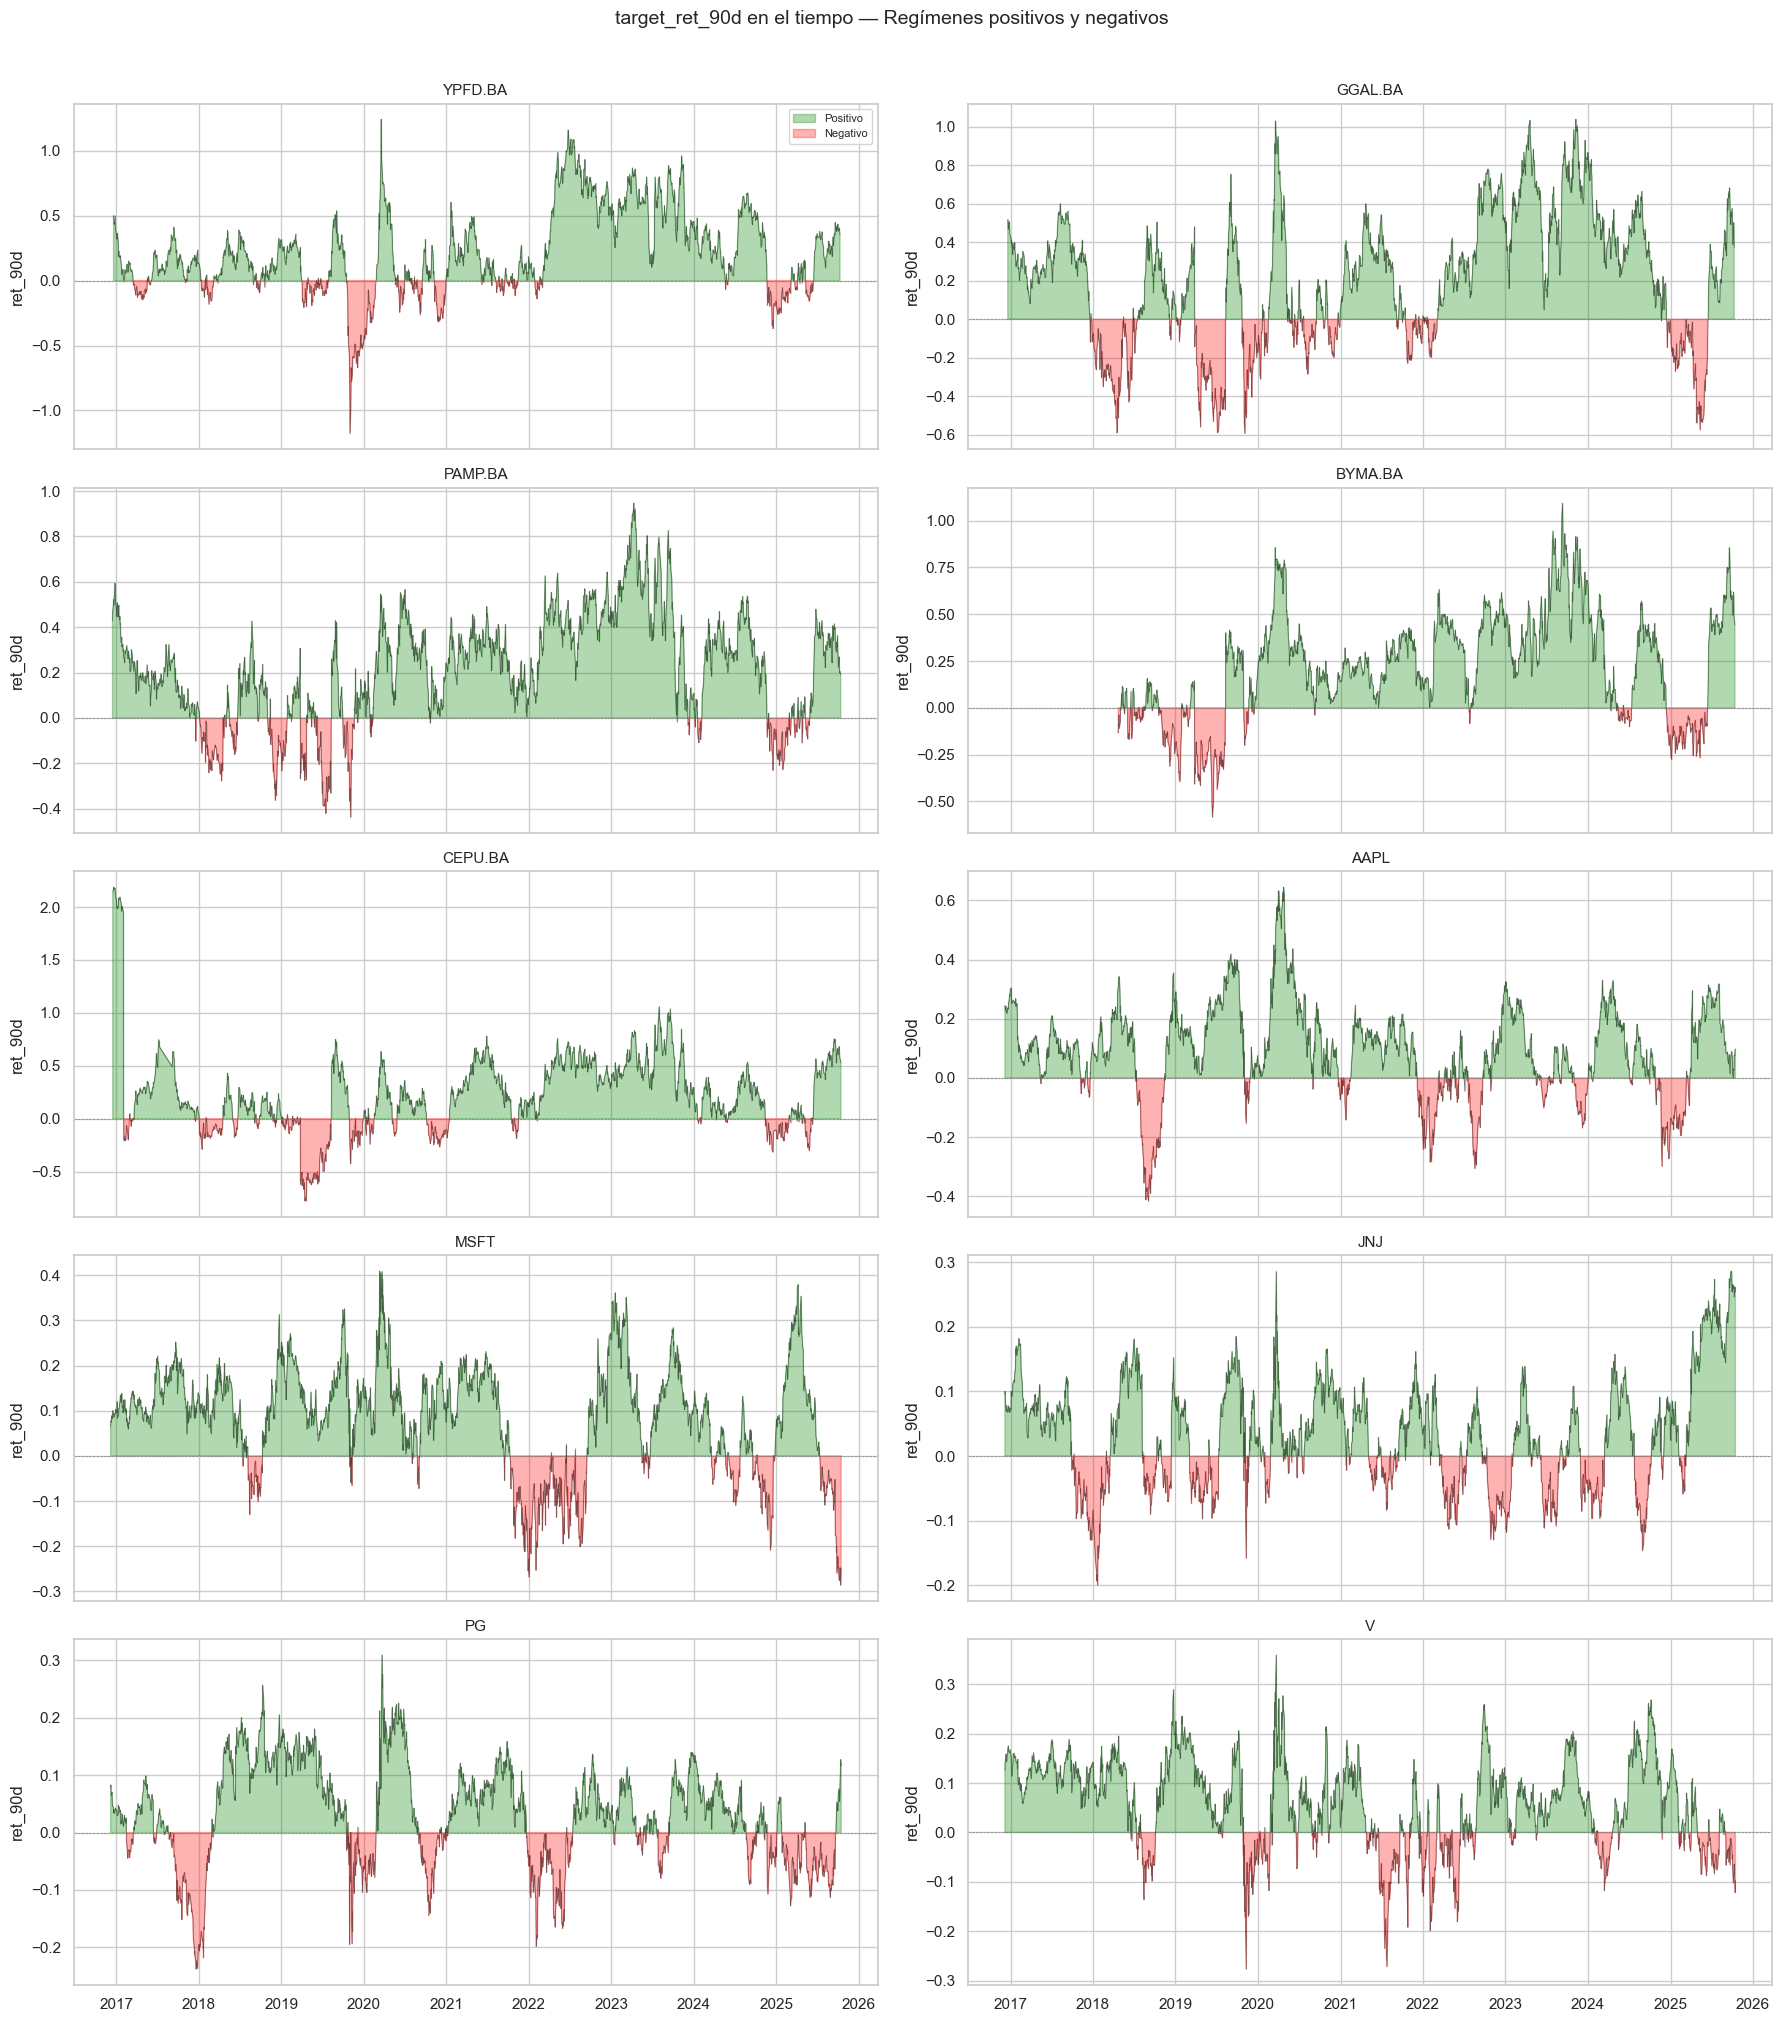

In [32]:
# --- Target en el tiempo: regímenes positivos y negativos ---
# Para cada ticker, graficamos el target_ret_90d como serie temporal.
# Verde = períodos donde el retorno a 90d fue positivo (mercado alcista)
# Rojo = períodos donde el retorno a 90d fue negativo (mercado bajista)
# Esto permite ver visualmente los "regímenes" de mercado.

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)  # sharex: mismo eje X (tiempo)
axes = axes.flatten()

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in targets_all:
        continue
    ax = axes[i]
    tgt = targets_all[ticker]

    # fill_between: colorea el área entre la línea y el eje Y=0
    # where=tgt >= 0: solo colorear donde el target es positivo (verde)
    ax.fill_between(tgt.index, tgt.values, 0,
                    where=tgt.values >= 0, color="green", alpha=0.3, label="Positivo")
    # where=tgt < 0: solo colorear donde el target es negativo (rojo)
    ax.fill_between(tgt.index, tgt.values, 0,
                    where=tgt.values < 0, color="red", alpha=0.3, label="Negativo")
    # Línea delgada negra para ver el contorno exacto
    ax.plot(tgt.index, tgt.values, color="black", linewidth=0.5, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")  # Línea horizontal en Y=0
    ax.set_title(f"{ticker}", fontsize=11)
    ax.set_ylabel(f"ret_{HORIZON}d")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(f"{target_name} en el tiempo — Regímenes positivos y negativos", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Análisis — Target en el tiempo**

La serie temporal del target revela **regímenes claros** de mercado:

- **Períodos prolongados positivos (verde)**: Se observan rachas de meses donde el retorno a 90 días es consistentemente positivo, indicando tendencias alcistas sostenidas. Esto es particularmente marcado en tickers AR, donde la inflación genera un sesgo alcista estructural.
- **Caídas sincronizadas**: Los períodos negativos (rojo) tienden a ocurrir simultáneamente entre tickers del mismo mercado (COVID-2020 es visible en todos). Esto indica **riesgo sistémico**: cuando el mercado cae, cae para todos.
- **Tickers AR vs US**: Los AR muestran mayor amplitud de oscilación (bandas más anchas de verde/rojo) y transiciones más abruptas entre regímenes. Los US muestran regímenes más prolongados y menos extremos.
- **Asimetría temporal**: Los períodos negativos tienden a ser más cortos pero más intensos que los positivos (caídas rápidas, recuperaciones lentas), especialmente en tickers US.

**Implicancia para el modelo**: La clara presencia de regímenes justifica el uso de **walk-forward validation** en lugar de un split temporal estático, ya que un split fijo podría entrenar en un régimen y testear en otro completamente distinto.

### 3.3 Autocorrelación del target (ACF / PACF)

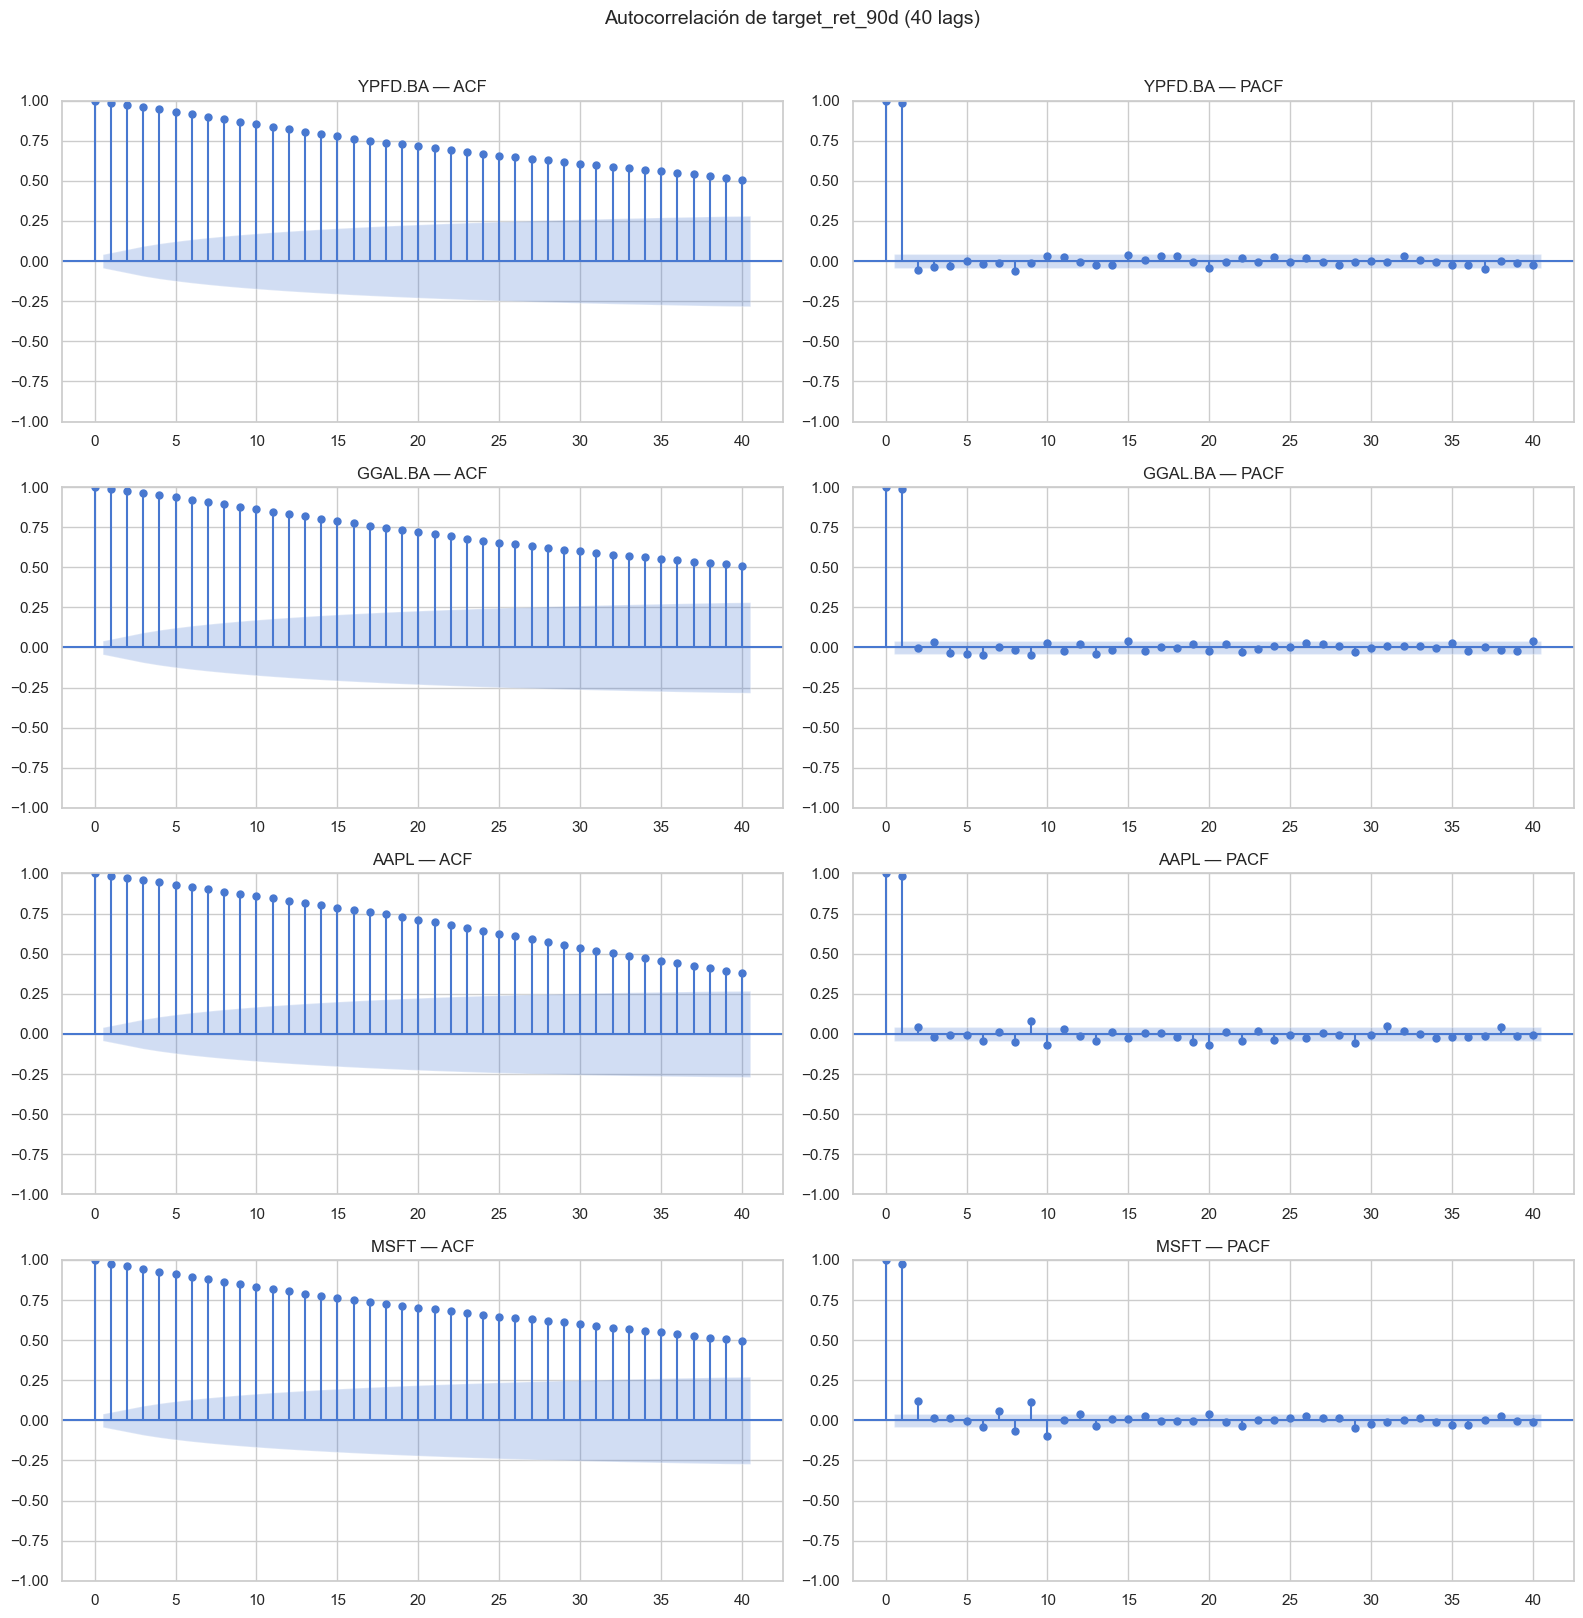

Nota: Alta autocorrelación es esperada porque el target usa ventanas de 90 días
superpuestas (retornos calculados diariamente). Esto NO es leakage,
pero sí implica que el walk-forward debe usar embargo >= 90 días.


In [33]:
# --- ACF / PACF del target ---
# ACF (Autocorrelation Function): mide la correlación del target consigo mismo
# desplazado en el tiempo (lags). Si ACF(lag=5) = 0.9, significa que el target
# de hoy y el de hace 5 días están 90% correlacionados.
#
# PACF (Partial ACF): similar pero "controlando" por los lags intermedios.
# Si PACF(lag=5) es alto pero PACF(lag=2,3,4) son bajos, la correlación en lag 5
# no se explica solo por la transmisión a través de lags 1→2→3→4→5.
#
# Se muestran 4 tickers representativos (2 AR + 2 US) para no sobrecargar el gráfico.

sample_tickers = [AR_TICKERS[0], AR_TICKERS[1], US_TICKERS[0], US_TICKERS[1]]
sample_tickers = [t for t in sample_tickers if t in targets_all]

fig, axes = plt.subplots(len(sample_tickers), 2, figsize=(16, 4 * len(sample_tickers)))

for i, ticker in enumerate(sample_tickers):
    tgt = targets_all[ticker].dropna()

    # lags=40: analizar correlación hasta 40 días de desfase
    # La banda azul sombreada indica el intervalo de confianza al 95%:
    # barras fuera de la banda = correlación estadísticamente significativa
    plot_acf(tgt, ax=axes[i, 0], lags=40, title=f"{ticker} — ACF")
    plot_pacf(tgt, ax=axes[i, 1], lags=40, title=f"{ticker} — PACF", method="ywm")

fig.suptitle(f"Autocorrelación de {target_name} (40 lags)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Nota: Alta autocorrelación es esperada porque el target usa ventanas de 90 días\n"
      "superpuestas (retornos calculados diariamente). Esto NO es leakage,\n"
      "pero sí implica que el walk-forward debe usar embargo >= 90 días.")

**Análisis — Autocorrelación del target**

Los gráficos ACF y PACF muestran **altísima autocorrelación** en el target, con coeficientes que decaen lentamente:

- **ACF**: Los coeficientes se mantienen significativos (fuera de la banda de confianza azul) hasta el lag 40 y más allá. El decaimiento es gradual, no hay un corte abrupto.
- **PACF**: Muestra un pico dominante en lag 1 y decae rápido. Esto indica que la autocorrelación se transmite principalmente a través de observaciones consecutivas.

**Causa**: Esta autocorrelación es **mecánica, no informativa**. El target `target_ret_90d` se calcula como el retorno acumulado en una ventana de 90 días deslizante día a día. Dos observaciones consecutivas (día t y día t+1) comparten 89 de 90 días en su ventana, por lo que están casi idénticamente correlacionadas.

**Consecuencia**: Sin un **embargo adecuado** en la validación temporal, el modelo podría "ver" información del test set a través de esta correlación mecánica. El embargo de 90 días configurado en `base.yaml` elimina exactamente esta dependencia, ya que garantiza que ninguna observación de test comparta días con el train set.

**Esto NO es leakage del modelo**, sino una propiedad intrínseca de targets con ventanas superpuestas. La configuración actual del pipeline (embargo >= horizonte) lo maneja correctamente.

### 3.4 Rolling mean y std del target

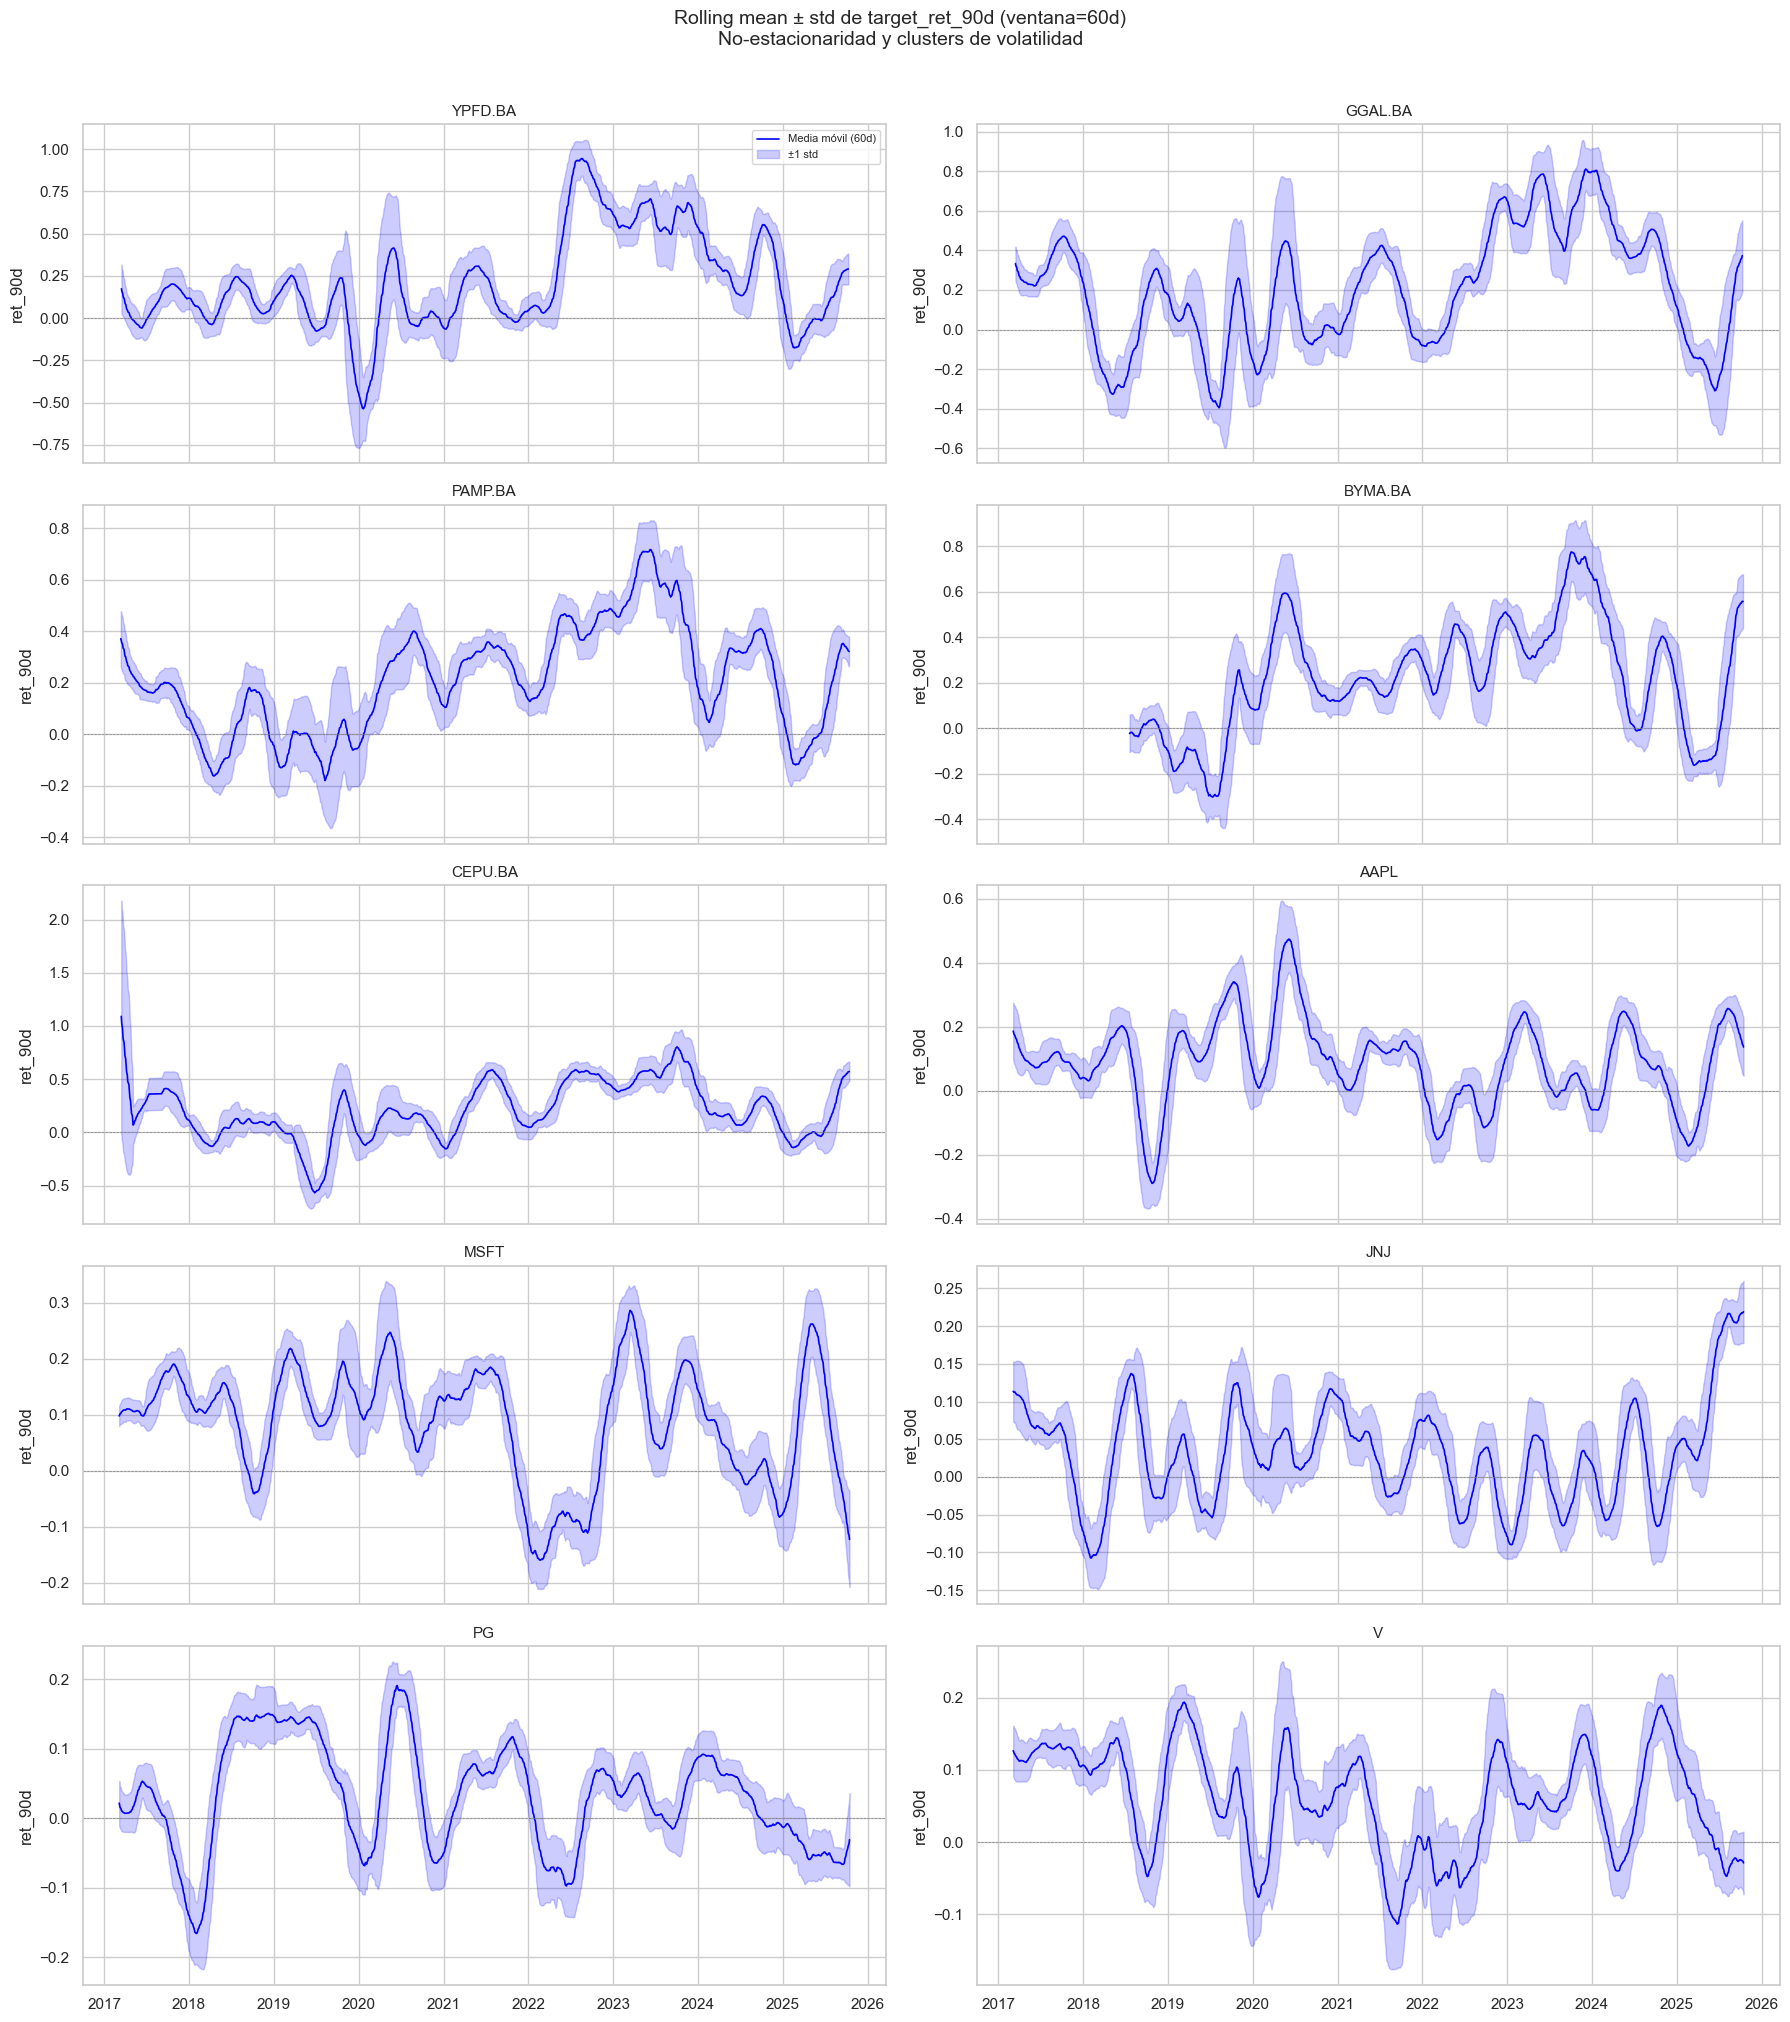

In [34]:
# --- Rolling mean y std del target ---
# "Rolling" = calcular un estadístico en una ventana deslizante de N días.
# Esto muestra cómo cambia la media y la volatilidad del target a lo largo del tiempo.
# Si la media y std fueran constantes, la serie sería "estacionaria".
# En la práctica, cambian mucho → el target es NO estacionario.

ROLLING_W = 60  # Ventana de 60 días (~3 meses)

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in targets_all:
        continue
    ax = axes[i]
    tgt = targets_all[ticker]

    # Media móvil: promedio del target en los últimos 60 días
    # Si sube → estamos en un período alcista. Si baja → bajista.
    roll_mean = tgt.rolling(ROLLING_W).mean()
    # Desviación estándar móvil: volatilidad del target en los últimos 60 días
    # Banda ancha = alta incertidumbre. Banda estrecha = mercado estable.
    roll_std = tgt.rolling(ROLLING_W).std()

    # Línea azul: media móvil
    ax.plot(roll_mean.index, roll_mean.values, color="blue", linewidth=1.2,
            label=f"Media móvil ({ROLLING_W}d)")
    # Banda azul sombreada: media ± 1 desviación estándar
    # Cubre ~68% de las observaciones si la distribución fuera normal
    ax.fill_between(roll_mean.index,
                    (roll_mean - roll_std).values,
                    (roll_mean + roll_std).values,
                    alpha=0.2, color="blue", label="±1 std")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(f"{ticker}", fontsize=11)
    ax.set_ylabel(f"ret_{HORIZON}d")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(f"Rolling mean ± std de {target_name} (ventana={ROLLING_W}d)\n"
             f"No-estacionaridad y clusters de volatilidad",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Análisis — Rolling mean y std del target**

Los gráficos de media móvil y banda de ±1 std confirman la **no-estacionaridad** del target:

- **Media variable en el tiempo**: La media del retorno a 90 días no es constante. Oscila entre valores fuertemente positivos (bull markets) y negativos (bear markets). No hay una media "global" que represente el proceso en todo momento.
- **Volatilidad variable** (clusters): Los períodos de alta volatilidad (bandas anchas) se alternan con períodos de baja volatilidad (bandas estrechas). Esto se conoce como **volatility clustering** y es una propiedad universal de series financieras.
- **Diferencia AR vs US**: Los tickers AR muestran bandas más anchas y media más alta (efecto inflación). Los US muestran bandas más estrechas con la media oscilando más cerca de cero.
- **COVID-2020**: Visible como un pico de volatilidad (bandas se expanden abruptamente) seguido de una compresión, en todos los tickers.

**Implicancia para el modelo**: 
1. La no-estacionaridad confirma que un modelo entrenado en un régimen puede fallar en otro. El **walk-forward** con ventanas deslizantes mitiga esto al reentrenar periódicamente.
2. La volatilidad variable sugiere que las predicciones del modelo serán más confiables en períodos de baja volatilidad y menos confiables en períodos turbulentos.

---
## 4. Resumen estadístico

### 4.1 Tabla de estadísticos por ticker

In [35]:
# --- Tabla resumen de estadísticos por ticker ---
# Calcula métricas descriptivas para retornos diarios y para el target (90d).
# Esto permite comparar cuantitativamente las diferencias entre tickers y mercados.

summary_rows = []
for ticker in E1_TICKERS:
    if ticker not in data:
        continue
    df = data[ticker]
    log_ret = np.log(df["close"]).diff().dropna()  # Retornos diarios
    tgt = targets_all.get(ticker)

    # Test de Jarque-Bera: contrasta la hipótesis "los datos son normales"
    # Si p < 0.05 → rechazamos normalidad (los datos NO son normales)
    # En finanzas, prácticamente siempre p ≈ 0 (nunca son normales)
    jb_stat, jb_p = stats.jarque_bera(log_ret)

    row = {
        "Ticker": ticker,
        "Mercado": "AR" if ticker.endswith(".BA") else "US",
        "N obs": len(df),
        # --- Estadísticos de retornos diarios ---
        "Ret diario μ": f"{log_ret.mean():.5f}",      # Retorno promedio diario
        "Ret diario σ": f"{log_ret.std():.4f}",        # Volatilidad diaria
        "Skewness": f"{stats.skew(log_ret):.2f}",      # Asimetría (<0 = caídas más severas)
        "Kurtosis (exc)": f"{stats.kurtosis(log_ret):.1f}",  # Colas pesadas (>0 = más extremos)
        "JB p-value": f"{jb_p:.1e}",                    # Test normalidad (p<0.05 → no normal)
    }

    if tgt is not None:
        row.update({
            # --- Estadísticos del target (retorno a 90 días) ---
            "Target μ": f"{tgt.mean():.4f}",    # Retorno promedio a 90d
            "Target σ": f"{tgt.std():.4f}",      # Volatilidad del target
            "Target min": f"{tgt.min():.3f}",    # Peor retorno a 90d observado
            "Target max": f"{tgt.max():.3f}",    # Mejor retorno a 90d observado
        })

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.style.set_caption("Estadísticos por ticker — E1 Conservative")

,Ticker,Mercado,N obs,Ret diario μ,Ret diario σ,Skewness,Kurtosis (exc),JB p-value,Target μ,Target σ,Target min,Target max
0,YPFD.BA,AR,2432,0.00216,0.0336,-0.04,9.9,0.0e+00,0.2126,0.3198,-1.176,1.242
1,GGAL.BA,AR,2433,0.00206,0.0366,-2.14,40.9,0.0e+00,0.2084,0.3340,-0.593,1.040
2,PAMP.BA,AR,2432,0.00238,0.0332,-2.18,44.7,0.0e+00,0.2168,0.2361,-0.438,0.946
3,BYMA.BA,AR,2109,0.00258,0.0324,-2.17,49.5,0.0e+00,0.2227,0.2802,-0.585,1.093
4,CEPU.BA,AR,2398,0.00325,0.0568,20.06,756.6,0.0e+00,0.2302,0.3813,-0.780,2.187
5,AAPL,US,2515,0.00101,0.0182,-0.08,6.8,0.0e+00,0.0886,0.1557,-0.417,0.645
6,MSFT,US,2515,0.00086,0.0169,-0.26,8.3,0.0e+00,0.0848,0.1187,-0.286,0.409
7,JNJ,US,2515,0.00044,0.0115,-0.46,10.2,0.0e+00,0.0329,0.0833,-0.200,0.286
8,PG,US,2515,0.00038,0.0118,-0.08,11.1,0.0e+00,0.0309,0.0867,-0.238,0.309
9,V,US,2515,0.00061,0.0153,-0.15,10.2,0.0e+00,0.0580,0.0902,-0.277,0.359


**Análisis — Tabla de estadísticos**

La tabla confirma cuantitativamente las observaciones previas:

- **Retorno diario medio**: AR (~0.002-0.003) > US (~0.0004-0.001). Los tickers argentinos tienen un drift positivo mayor, dominado por la inflación/devaluación.
- **Volatilidad diaria**: AR (3.2-5.7%) > US (1.2-1.8%). CEPU.BA es el más volátil (5.7%), JNJ el menos volátil (1.2%).
- **No-normalidad universal**: Jarque-Bera p=0.0 para todos los tickers. Ninguno pasa el test de normalidad.
- **Kurtosis**: Todos tienen excess kurtosis > 6, indicando colas pesadas. Los tickers AR son particularmente leptocúrticos (especialmente CEPU con ku=756.6).
- **Target a 90 días**: La dispersión (σ) del target AR (0.24-0.38) es 2-4x mayor que la del target US (0.08-0.16). Esto significa que predecir retornos de tickers argentinos es inherentemente más difícil.

### 4.2 Heatmap cross-ticker de features

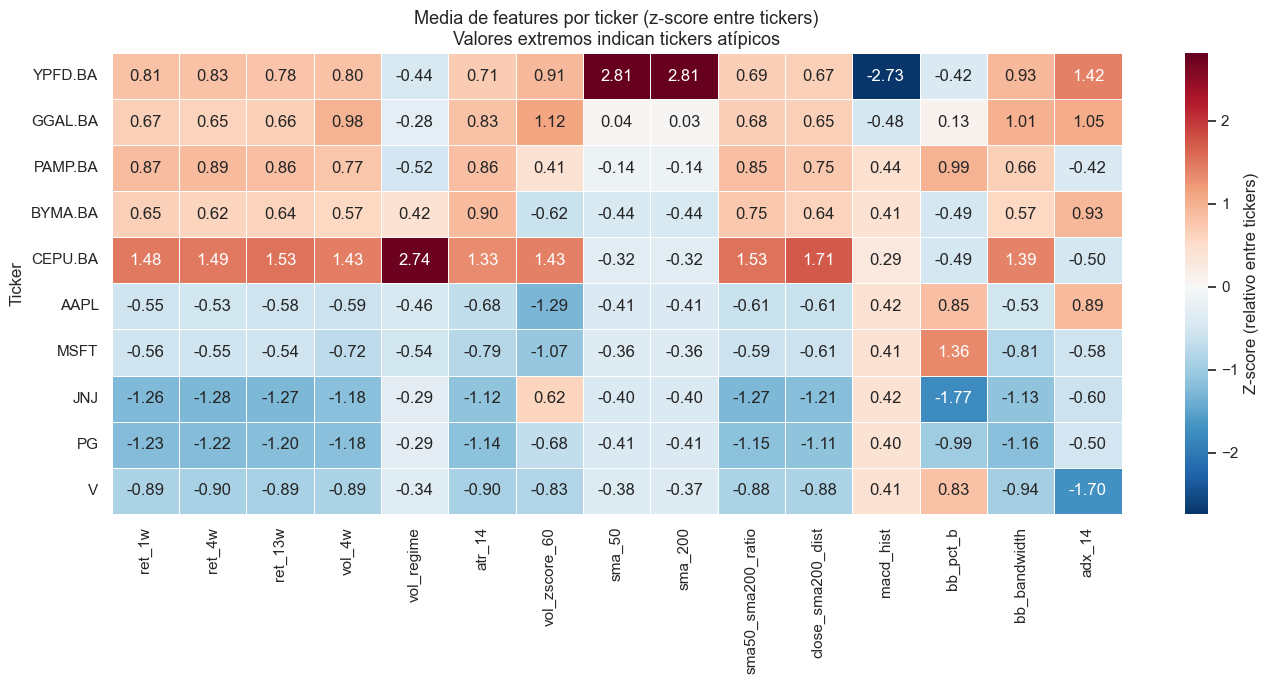

In [36]:
# --- Heatmap cross-ticker: media de cada feature por ticker ---
# Cada celda muestra la media de un feature para un ticker específico.
# Como los features tienen escalas muy distintas (ej: sma_200 ~ 100-500 vs bb_pct_b ~ 0-1),
# estandarizamos por columna (z-score entre tickers) para poder comparar visualmente.
# Z-score = (valor - media_entre_tickers) / std_entre_tickers
# Valores extremos (|z| > 2) indican tickers que se comportan muy diferente del grupo.

# Calcular la media de cada feature para cada ticker
feat_means = pd.DataFrame({
    ticker: features_all[ticker].mean()
    for ticker in E1_TICKERS if ticker in features_all
}).T  # Transponer: filas=tickers, columnas=features

# Estandarizar por columna (z-score entre tickers, no entre features)
# Así podemos ver qué tickers son atípicos para cada feature
feat_means_z = (feat_means - feat_means.mean()) / (feat_means.std() + 1e-12)

fig, ax = plt.subplots(figsize=(14, 7))
# cmap="RdBu_r": rojo = z-score positivo (mayor que el promedio del grupo)
#                azul = z-score negativo (menor que el promedio del grupo)
sns.heatmap(feat_means_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "Z-score (relativo entre tickers)"})
ax.set_title("Media de features por ticker (z-score entre tickers)\n"
             "Valores extremos indican tickers atípicos", fontsize=13)
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.show()

---
## 5. Conclusiones del EDA

### Hallazgos principales

1. **Los retornos financieros no son normales**: Todos los tickers rechazan normalidad (Jarque-Bera p=0.0) con excess kurtosis entre 6.8 (AAPL) y 756.6 (CEPU.BA). Esto justifica el uso de **loss function Huber** (robusta a outliers) y **modelos no lineales** (GRU) en lugar de regresión lineal.

2. **Dos universos con escalas distintas**: Los tickers argentinos tienen retornos nominales ~3-7x mayores y volatilidad ~2-3x mayor que los estadounidenses, debido al efecto inflación/devaluación del peso. Esto valida la decisión de:
   - Normalizar features y target con **Z-score por ticker** (no pooled)
   - Entrenar **modelos independientes** por ticker

3. **Multicolinealidad detectada**: 6 pares de features con |r| > 0.7. En particular, `sma_50` y `sma_200` son casi redundantes (r=0.987) porque son precios absolutos. La señal útil ya está capturada en `sma50_sma200_ratio` y `close_sma200_dist`. Se recomienda evaluar si eliminar `sma_50` y `sma_200` como features directas mejora la estabilidad del modelo.

4. **Features más predictivos del target**: `atr_14` (r=0.32) y `sma50_sma200_ratio` (r=0.31) son los features con mayor correlación lineal con el target a 90 días. Los features de momentum corto (`ret_1w`, `ret_4w`) tienen correlación negativa débil, sugiriendo **mean-reversion** leve a corto plazo.

5. **No-estacionaridad del target**: La media y varianza del retorno a 90 días cambian en el tiempo (regímenes bull/bear visibles). Esto justifica el uso de **walk-forward validation** con reentrenamiento periódico, en lugar de un split temporal fijo.

6. **Autocorrelación mecánica del target**: Esperada por las ventanas superpuestas de 90 días. El embargo de 90 días configurado en el pipeline lo maneja correctamente.

### Recomendaciones para el modelado

- **Monitorear CEPU.BA**: Su kurtosis extrema (756.6) y retorno máximo de +219% en 90 días podrían distorsionar el entrenamiento. Considerar clipear outliers o evaluar su impacto en las métricas.
- **Evaluar la eliminación de features redundantes**: `sma_50`, `sma_200`, y posiblemente uno de `vol_4w`/`bb_bandwidth` podrían eliminarse sin perder información, reduciendo el riesgo de multicolinealidad.
- **Considerar features adicionales**: `vol_regime` (r=0.002, p=0.76) no muestra relación lineal con el target. Su utilidad depende de que el GRU capture patrones no lineales que justifiquen su inclusión.